In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Output directory with all results
OUTPUT_DIR = 'outputs'

print("✓ Imports successful")

✓ Imports successful


# Feature Selection Analysis

This notebook analyzes feature selection results from per-year CSV files only.

## 1. Load Feature Selection Data from Per-Year Files

In [2]:
# Load all feature selection history files (fs_history_YEAR_MODEL_METRIC.csv)
fs_history_files = glob.glob(os.path.join(OUTPUT_DIR, 'fs_history_*.csv'))
fs_histories = {}

for f in fs_history_files:
    # Parse filename: fs_history_YEAR_MODEL_METRIC.csv
    basename = os.path.basename(f).replace('.csv', '').replace('fs_history_', '')
    parts = basename.split('_')
    year = int(parts[0])
    model = parts[1]
    metric = '_'.join(parts[2:])  # Handle 'worst_case'
    
    key = (year, model, metric)
    df = pd.read_csv(f)
    df['year'] = year
    df['model'] = model
    df['metric'] = metric
    fs_histories[key] = df

print(f"✓ Loaded {len(fs_histories)} feature selection history files")
years = sorted(set(k[0] for k in fs_histories.keys()))
print(f"Years: {years[0]} - {years[-1]} ({len(years)} years)")
print(f"Models: {sorted(set(k[1] for k in fs_histories.keys()))}")
print(f"Metrics: {sorted(set(k[2] for k in fs_histories.keys()))}")

✓ Loaded 104 feature selection history files
Years: 1991 - 2018 (26 years)
Models: ['Ridge', 'XGBoost']
Metrics: ['rmse', 'worst_case']


In [3]:
# Load per-year feature selection summaries (fs_summary_YEAR.csv)
fs_summary_files = glob.glob(os.path.join(OUTPUT_DIR, 'fs_summary_*.csv'))
fs_summaries = []

for f in fs_summary_files:
    df = pd.read_csv(f)
    fs_summaries.append(df)

fs_summary = pd.concat(fs_summaries, ignore_index=True)

print(f"✓ Loaded {len(fs_summary_files)} per-year summary files")
print(f"Total feature selection runs: {len(fs_summary)}")
print(f"\nColumns: {fs_summary.columns.tolist()}")
display(fs_summary.head())

✓ Loaded 26 per-year summary files
Total feature selection runs: 104

Columns: ['target_year', 'selection', 'model', 'optimize_metric', 'n_features', 'final_rmse', 'final_worst_case', 'selected_features']


,target_year,selection,model,optimize_metric,n_features,final_rmse,final_worst_case,selected_features
0,1991,Ridge_rmse,Ridge,rmse,5,1.817734,5.447827,delta_u10_lag1 | delta_v10_lag1 | delta_Mortal...
1,1991,Ridge_worst_case,Ridge,worst_case,7,2.032341,3.626777,delta_u10_lag1 | delta_Sulfur emission_lag1 | ...
2,1991,XGBoost_rmse,XGBoost,rmse,3,1.659640,3.545098,delta_Coal consumption_lag1 | delta_u10_lag1 |...
3,1991,XGBoost_worst_case,XGBoost,worst_case,4,2.038920,3.837070,"delta_Life expectancy at birth, total (years)_..."
4,1992,Ridge_rmse,Ridge,rmse,10,1.051000,2.656418,delta_u10_lag2 | delta_CO2 emissions_lag1 | de...


## 2. Feature Selection Overview

In [4]:
# Feature selection summary by model and optimization metric
print("=" * 80)
print("FEATURE SELECTION SUMMARY BY MODEL AND METRIC")
print("=" * 80)

for model in fs_summary['model'].unique():
    print(f"\n### {model} ###")
    model_data = fs_summary[fs_summary['model'] == model]
    
    for metric in model_data['optimize_metric'].unique():
        metric_data = model_data[model_data['optimize_metric'] == metric]
        
        print(f"\n  {metric.upper()} optimization ({len(metric_data)} years):")
        print(f"    Features selected: {metric_data['n_features'].mean():.1f} ± {metric_data['n_features'].std():.1f}")
        print(f"    Range: {metric_data['n_features'].min()} - {metric_data['n_features'].max()}")
        print(f"    Final RMSE:       {metric_data['final_rmse'].mean():.4f} ± {metric_data['final_rmse'].std():.4f}")
        print(f"    Final Worst-Case: {metric_data['final_worst_case'].mean():.4f} ± {metric_data['final_worst_case'].std():.4f}")

FEATURE SELECTION SUMMARY BY MODEL AND METRIC

### Ridge ###

  RMSE optimization (26 years):
    Features selected: 9.3 ± 5.6
    Range: 4 - 23
    Final RMSE:       0.5347 ± 0.3358
    Final Worst-Case: 1.2791 ± 1.0476

  WORST_CASE optimization (26 years):
    Features selected: 7.1 ± 2.0
    Range: 4 - 12
    Final RMSE:       0.8765 ± 0.5034
    Final Worst-Case: 1.3197 ± 0.8914

### XGBoost ###

  RMSE optimization (26 years):
    Features selected: 6.8 ± 2.6
    Range: 3 - 13
    Final RMSE:       1.4381 ± 0.3662
    Final Worst-Case: 3.3948 ± 1.0164

  WORST_CASE optimization (26 years):
    Features selected: 4.5 ± 1.8
    Range: 2 - 9
    Final RMSE:       1.8933 ± 0.6158
    Final Worst-Case: 3.1105 ± 0.9215


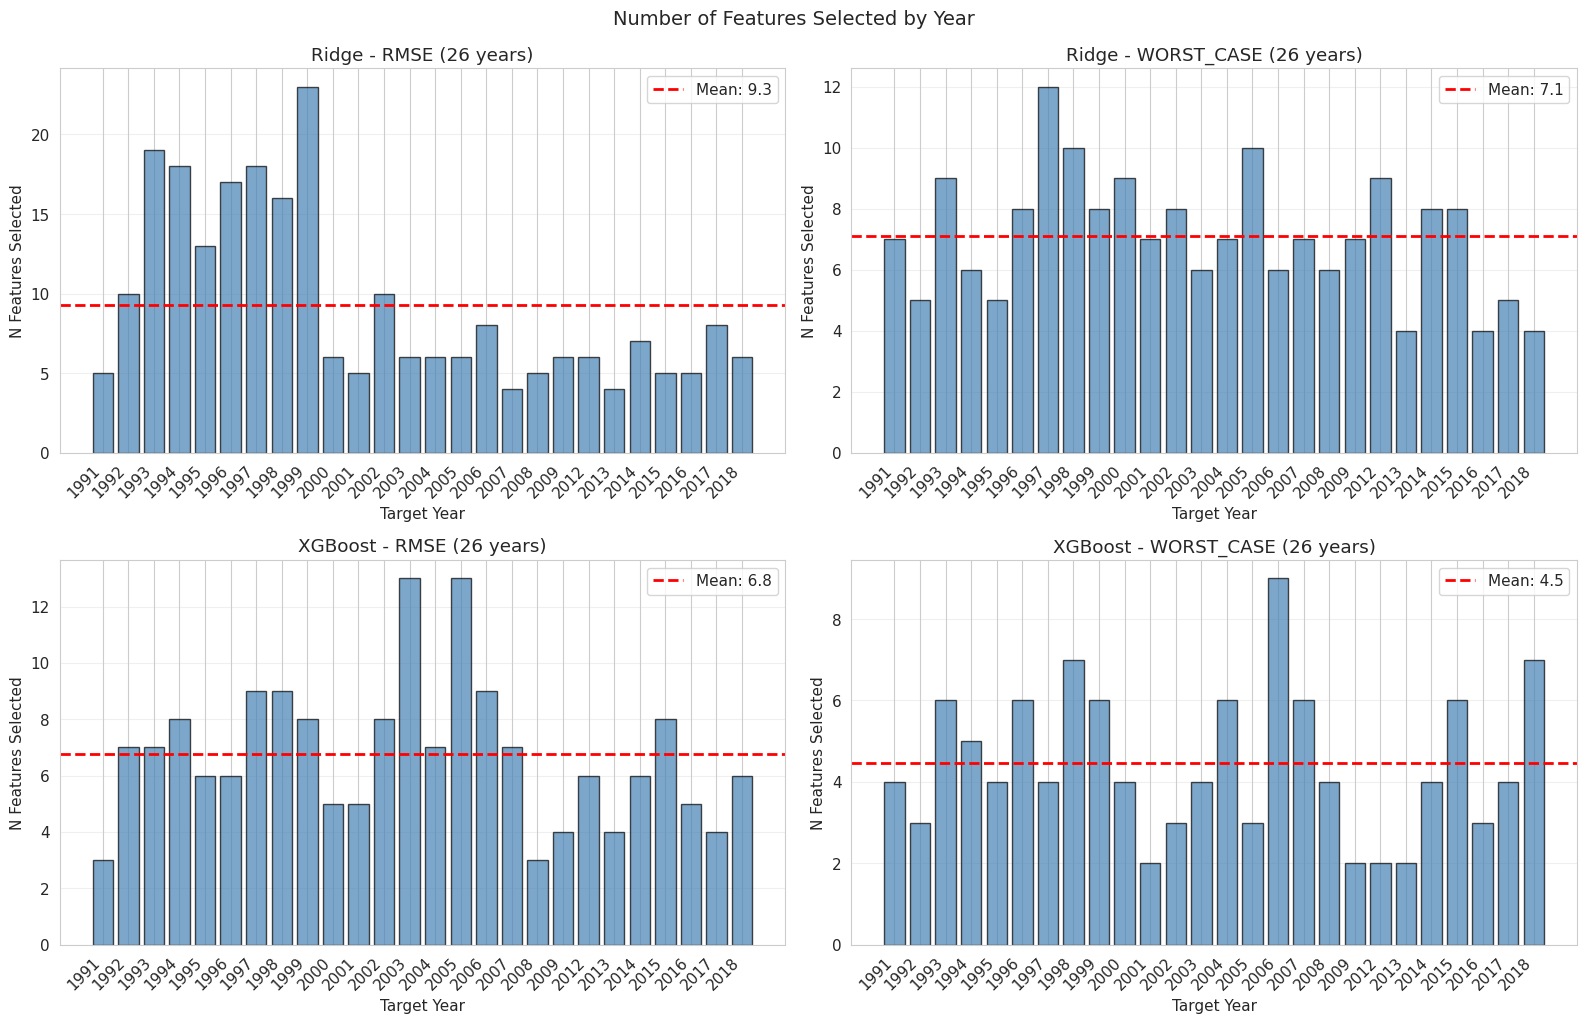

In [5]:
# Number of features selected by year
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (model, metric) in enumerate([('Ridge', 'rmse'), ('Ridge', 'worst_case'), 
                                        ('XGBoost', 'rmse'), ('XGBoost', 'worst_case')]):
    ax = axes[idx // 2, idx % 2]
    
    data = fs_summary[(fs_summary['model'] == model) & (fs_summary['optimize_metric'] == metric)]
    data = data.sort_values('target_year')
    
    bars = ax.bar(range(len(data)), data['n_features'].values, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axhline(data['n_features'].mean(), color='red', linestyle='--', linewidth=2,
               label=f"Mean: {data['n_features'].mean():.1f}")
    
    ax.set_xlabel('Target Year')
    ax.set_ylabel('N Features Selected')
    ax.set_title(f'{model} - {metric.upper()} ({len(data)} years)')
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data['target_year'].astype(int), rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('Number of Features Selected by Year', y=1.02, fontsize=14)
plt.show()

## 3. Feature Selection Performance by Year

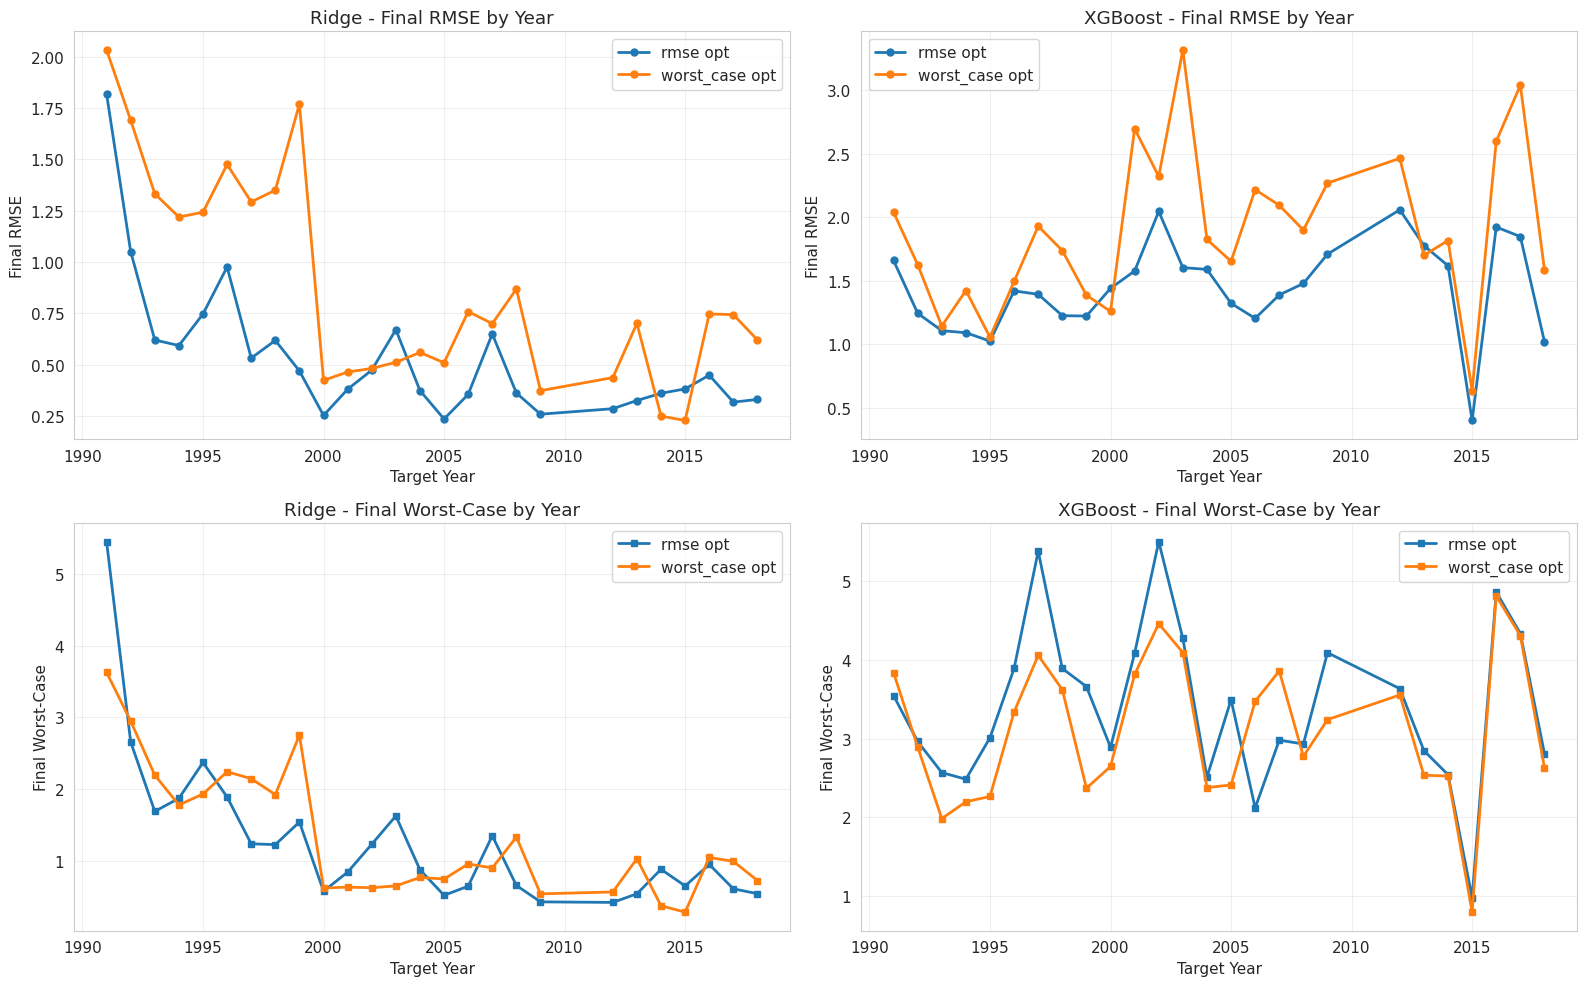

In [6]:
# Plot RMSE and Worst-Case by year for each selection type
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# RMSE by year
for idx, model in enumerate(['Ridge', 'XGBoost']):
    ax = axes[0, idx]
    
    for metric in ['rmse', 'worst_case']:
        data = fs_summary[(fs_summary['model'] == model) & (fs_summary['optimize_metric'] == metric)]
        data = data.sort_values('target_year')
        ax.plot(data['target_year'], data['final_rmse'], 'o-', label=f'{metric} opt', linewidth=2, markersize=5)
    
    ax.set_xlabel('Target Year')
    ax.set_ylabel('Final RMSE')
    ax.set_title(f'{model} - Final RMSE by Year')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Worst-case by year
for idx, model in enumerate(['Ridge', 'XGBoost']):
    ax = axes[1, idx]
    
    for metric in ['rmse', 'worst_case']:
        data = fs_summary[(fs_summary['model'] == model) & (fs_summary['optimize_metric'] == metric)]
        data = data.sort_values('target_year')
        ax.plot(data['target_year'], data['final_worst_case'], 's-', label=f'{metric} opt', linewidth=2, markersize=5)
    
    ax.set_xlabel('Target Year')
    ax.set_ylabel('Final Worst-Case')
    ax.set_title(f'{model} - Final Worst-Case by Year')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Best and worst years for each selection type
print("=" * 80)
print("BEST AND WORST YEARS BY SELECTION TYPE")
print("=" * 80)

for selection in fs_summary['selection'].unique():
    sel_data = fs_summary[fs_summary['selection'] == selection].copy()
    
    # Determine which metric to use based on optimization target
    metric_col = 'final_rmse' if 'rmse' in selection else 'final_worst_case'
    
    best_idx = sel_data[metric_col].idxmin()
    worst_idx = sel_data[metric_col].idxmax()
    
    best_row = sel_data.loc[best_idx]
    worst_row = sel_data.loc[worst_idx]
    
    print(f"\n[{selection}]")
    print(f"  Best year:  {int(best_row['target_year'])} - {metric_col}={best_row[metric_col]:.4f}, n_features={int(best_row['n_features'])}")
    print(f"  Worst year: {int(worst_row['target_year'])} - {metric_col}={worst_row[metric_col]:.4f}, n_features={int(worst_row['n_features'])}")

BEST AND WORST YEARS BY SELECTION TYPE

[Ridge_rmse]
  Best year:  2005 - final_rmse=0.2362, n_features=6
  Worst year: 1991 - final_rmse=1.8177, n_features=5

[Ridge_worst_case]
  Best year:  2015 - final_worst_case=0.2834, n_features=8
  Worst year: 1991 - final_worst_case=3.6268, n_features=7

[XGBoost_rmse]
  Best year:  2015 - final_rmse=0.4004, n_features=8
  Worst year: 2012 - final_rmse=2.0585, n_features=6

[XGBoost_worst_case]
  Best year:  2015 - final_worst_case=0.7981, n_features=6
  Worst year: 2016 - final_worst_case=4.8102, n_features=3


## 4. Most Frequently Selected Features

In [8]:
# Extract all selected features from per-year summaries
all_features = []

for _, row in fs_summary.iterrows():
    features = row['selected_features'].split(' | ')
    for f in features:
        all_features.append({
            'feature': f.strip(),
            'model': row['model'],
            'optimized_for': row['optimize_metric'],
            'year': row['target_year'],
            'selection': row['selection']
        })

features_df = pd.DataFrame(all_features)
n_selections = len(fs_summary)

# Count occurrences
feature_counts = features_df.groupby('feature').size().sort_values(ascending=False)

print("=" * 80)
print(f"TOP 20 MOST FREQUENTLY SELECTED FEATURES")
print(f"(across {n_selections} total selection runs)")
print("=" * 80)
for i, (feat, count) in enumerate(feature_counts.head(20).items(), 1):
    pct = 100 * count / n_selections
    print(f"{i:2d}. {feat}: {count} times ({pct:.1f}%)")

TOP 20 MOST FREQUENTLY SELECTED FEATURES
(across 104 total selection runs)
 1. delta_Renewable electricity output (% of total electricity output)_lag1: 10 times (9.6%)
 2. delta_t2m_lag1: 9 times (8.7%)
 3. delta_Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)_lag1: 8 times (7.7%)
 4. delta_Access to electricity (% of population)_lag1: 8 times (7.7%)
 5. delta_u10_lag3: 8 times (7.7%)
 6. delta_sst_lag3: 8 times (7.7%)
 7. delta_Energy use_lag2: 7 times (6.7%)
 8. delta_Electricity use_lag1: 7 times (6.7%)
 9. delta_blh_lag1: 7 times (6.7%)
10. delta_u10_lag1: 7 times (6.7%)
11. delta_Renewable electricity output (% of total electricity output)_lag3: 7 times (6.7%)
12. delta_Sulfur emission_lag1: 7 times (6.7%)
13. delta_Gini index_lag11: 6 times (5.8%)
14. delta_Surface area (sq. km)_lag1: 6 times (5.8%)
15. delta_Compulsory education, duration (years)_lag1: 6 times (5.8%)
16. delta_d2m_lag1: 6 times (5.8%)
17. delta_u10_lag2: 6 times (5.8%)
18. delta_Gini i

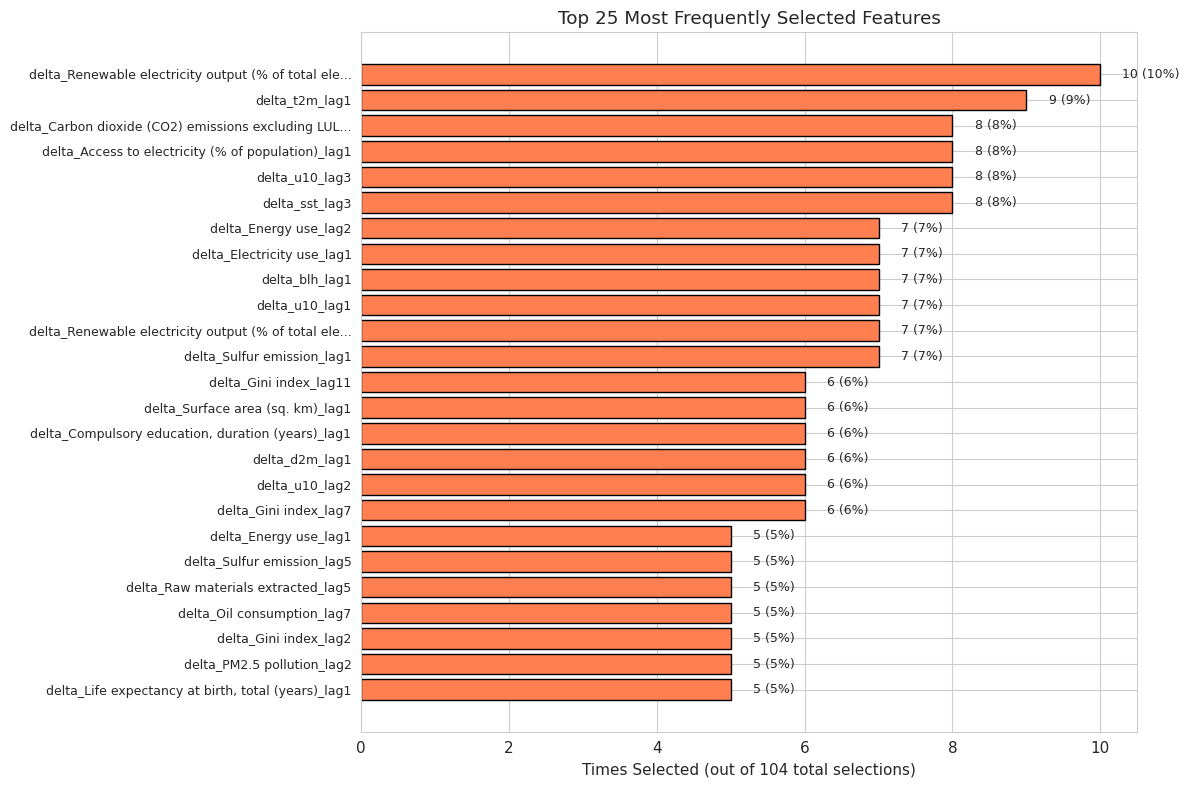

In [9]:
# Plot top features
top_n = 25
top_features = feature_counts.head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top_features)), top_features.values, color='coral', edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels([f[:50] + '...' if len(f) > 50 else f for f in top_features.index], fontsize=9)
ax.set_xlabel(f'Times Selected (out of {n_selections} total selections)')
ax.set_title(f'Top {top_n} Most Frequently Selected Features')
ax.invert_yaxis()

# Add count labels with percentage
for bar, count in zip(bars, top_features.values):
    pct = 100 * count / n_selections
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{count} ({pct:.0f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

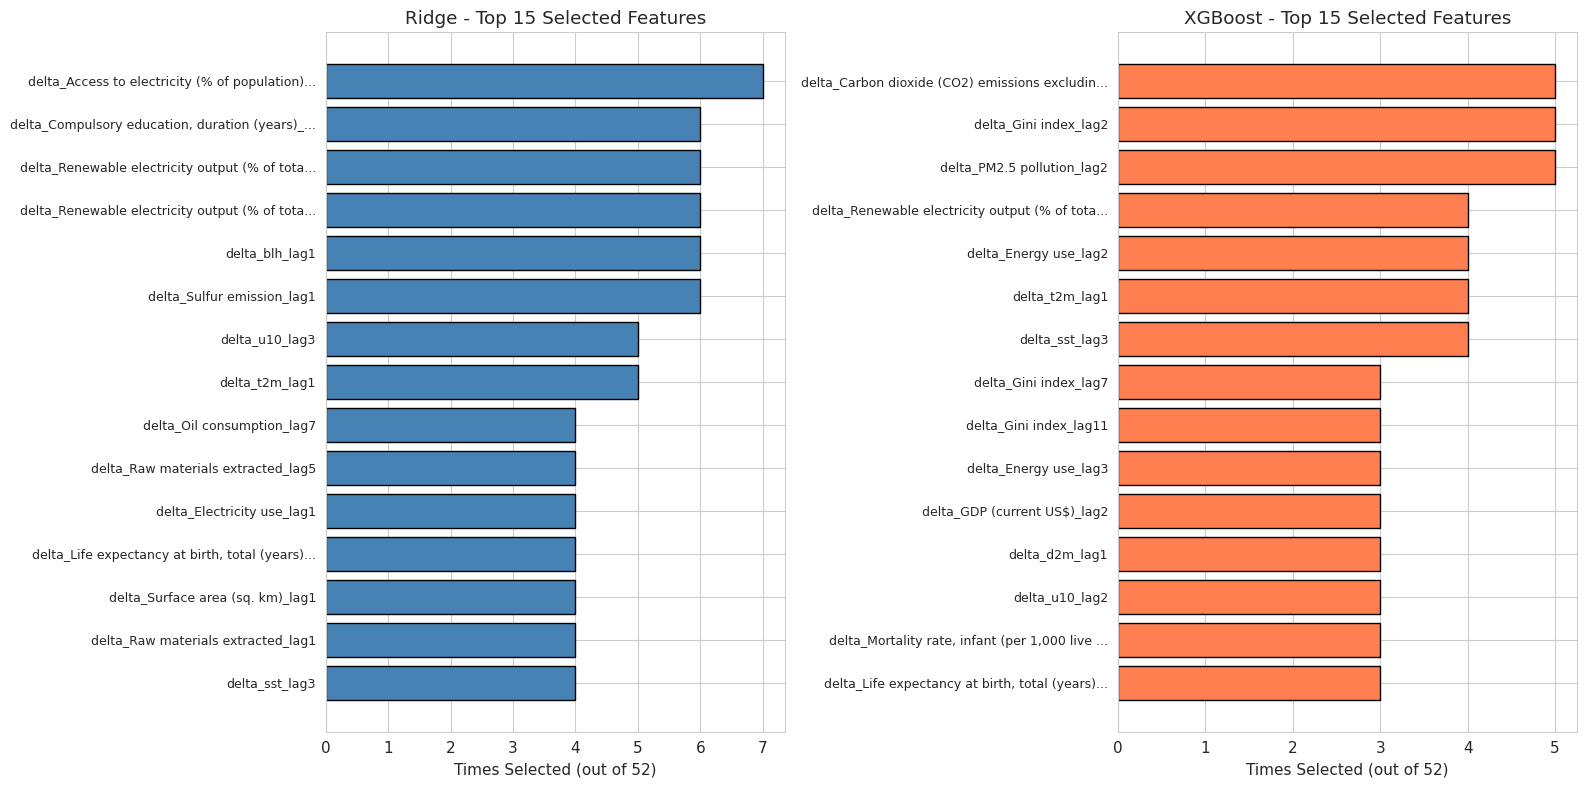

In [10]:
# Top features by model
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for idx, model in enumerate(['Ridge', 'XGBoost']):
    ax = axes[idx]
    model_features = features_df[features_df['model'] == model]
    model_counts = model_features.groupby('feature').size().sort_values(ascending=False).head(15)
    n_model_selections = len(fs_summary[fs_summary['model'] == model])
    
    bars = ax.barh(range(len(model_counts)), model_counts.values, 
                   color='steelblue' if model == 'Ridge' else 'coral', edgecolor='black')
    ax.set_yticks(range(len(model_counts)))
    ax.set_yticklabels([f[:45] + '...' if len(f) > 45 else f for f in model_counts.index], fontsize=9)
    ax.set_xlabel(f'Times Selected (out of {n_model_selections})')
    ax.set_title(f'{model} - Top 15 Selected Features')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


Ridge - RMSE - Top 15 Features:
 1. delta_Access to electricity (% of population)_lag1: 5 times (19.2%)
 2. delta_Renewable electricity output (% of total electricity output)_lag1: 4 times (15.4%)
 3. delta_blh_lag1: 4 times (15.4%)
 4. delta_t2m_lag1: 4 times (15.4%)
 5. delta_Energy use_lag2: 3 times (11.5%)
 6. delta_Renewable electricity output (% of total electricity output)_lag2: 3 times (11.5%)
 7. delta_Gini index_lag5: 3 times (11.5%)
 8. delta_GDP per capita (constant 2015 US$)_lag1: 3 times (11.5%)
 9. delta_Compulsory education, duration (years)_lag1: 3 times (11.5%)
10. delta_Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)_lag1: 3 times (11.5%)
11. delta_Life expectancy at birth, total (years)_lag1: 3 times (11.5%)
12. delta_Raw materials extracted_lag1: 3 times (11.5%)
13. delta_Unemployment, total (% of total labor force) (national estimate)_lag3: 3 times (11.5%)
14. delta_Surface area (sq. km)_lag2: 3 times (11.5%)
15. delta_u10_lag1: 3 times

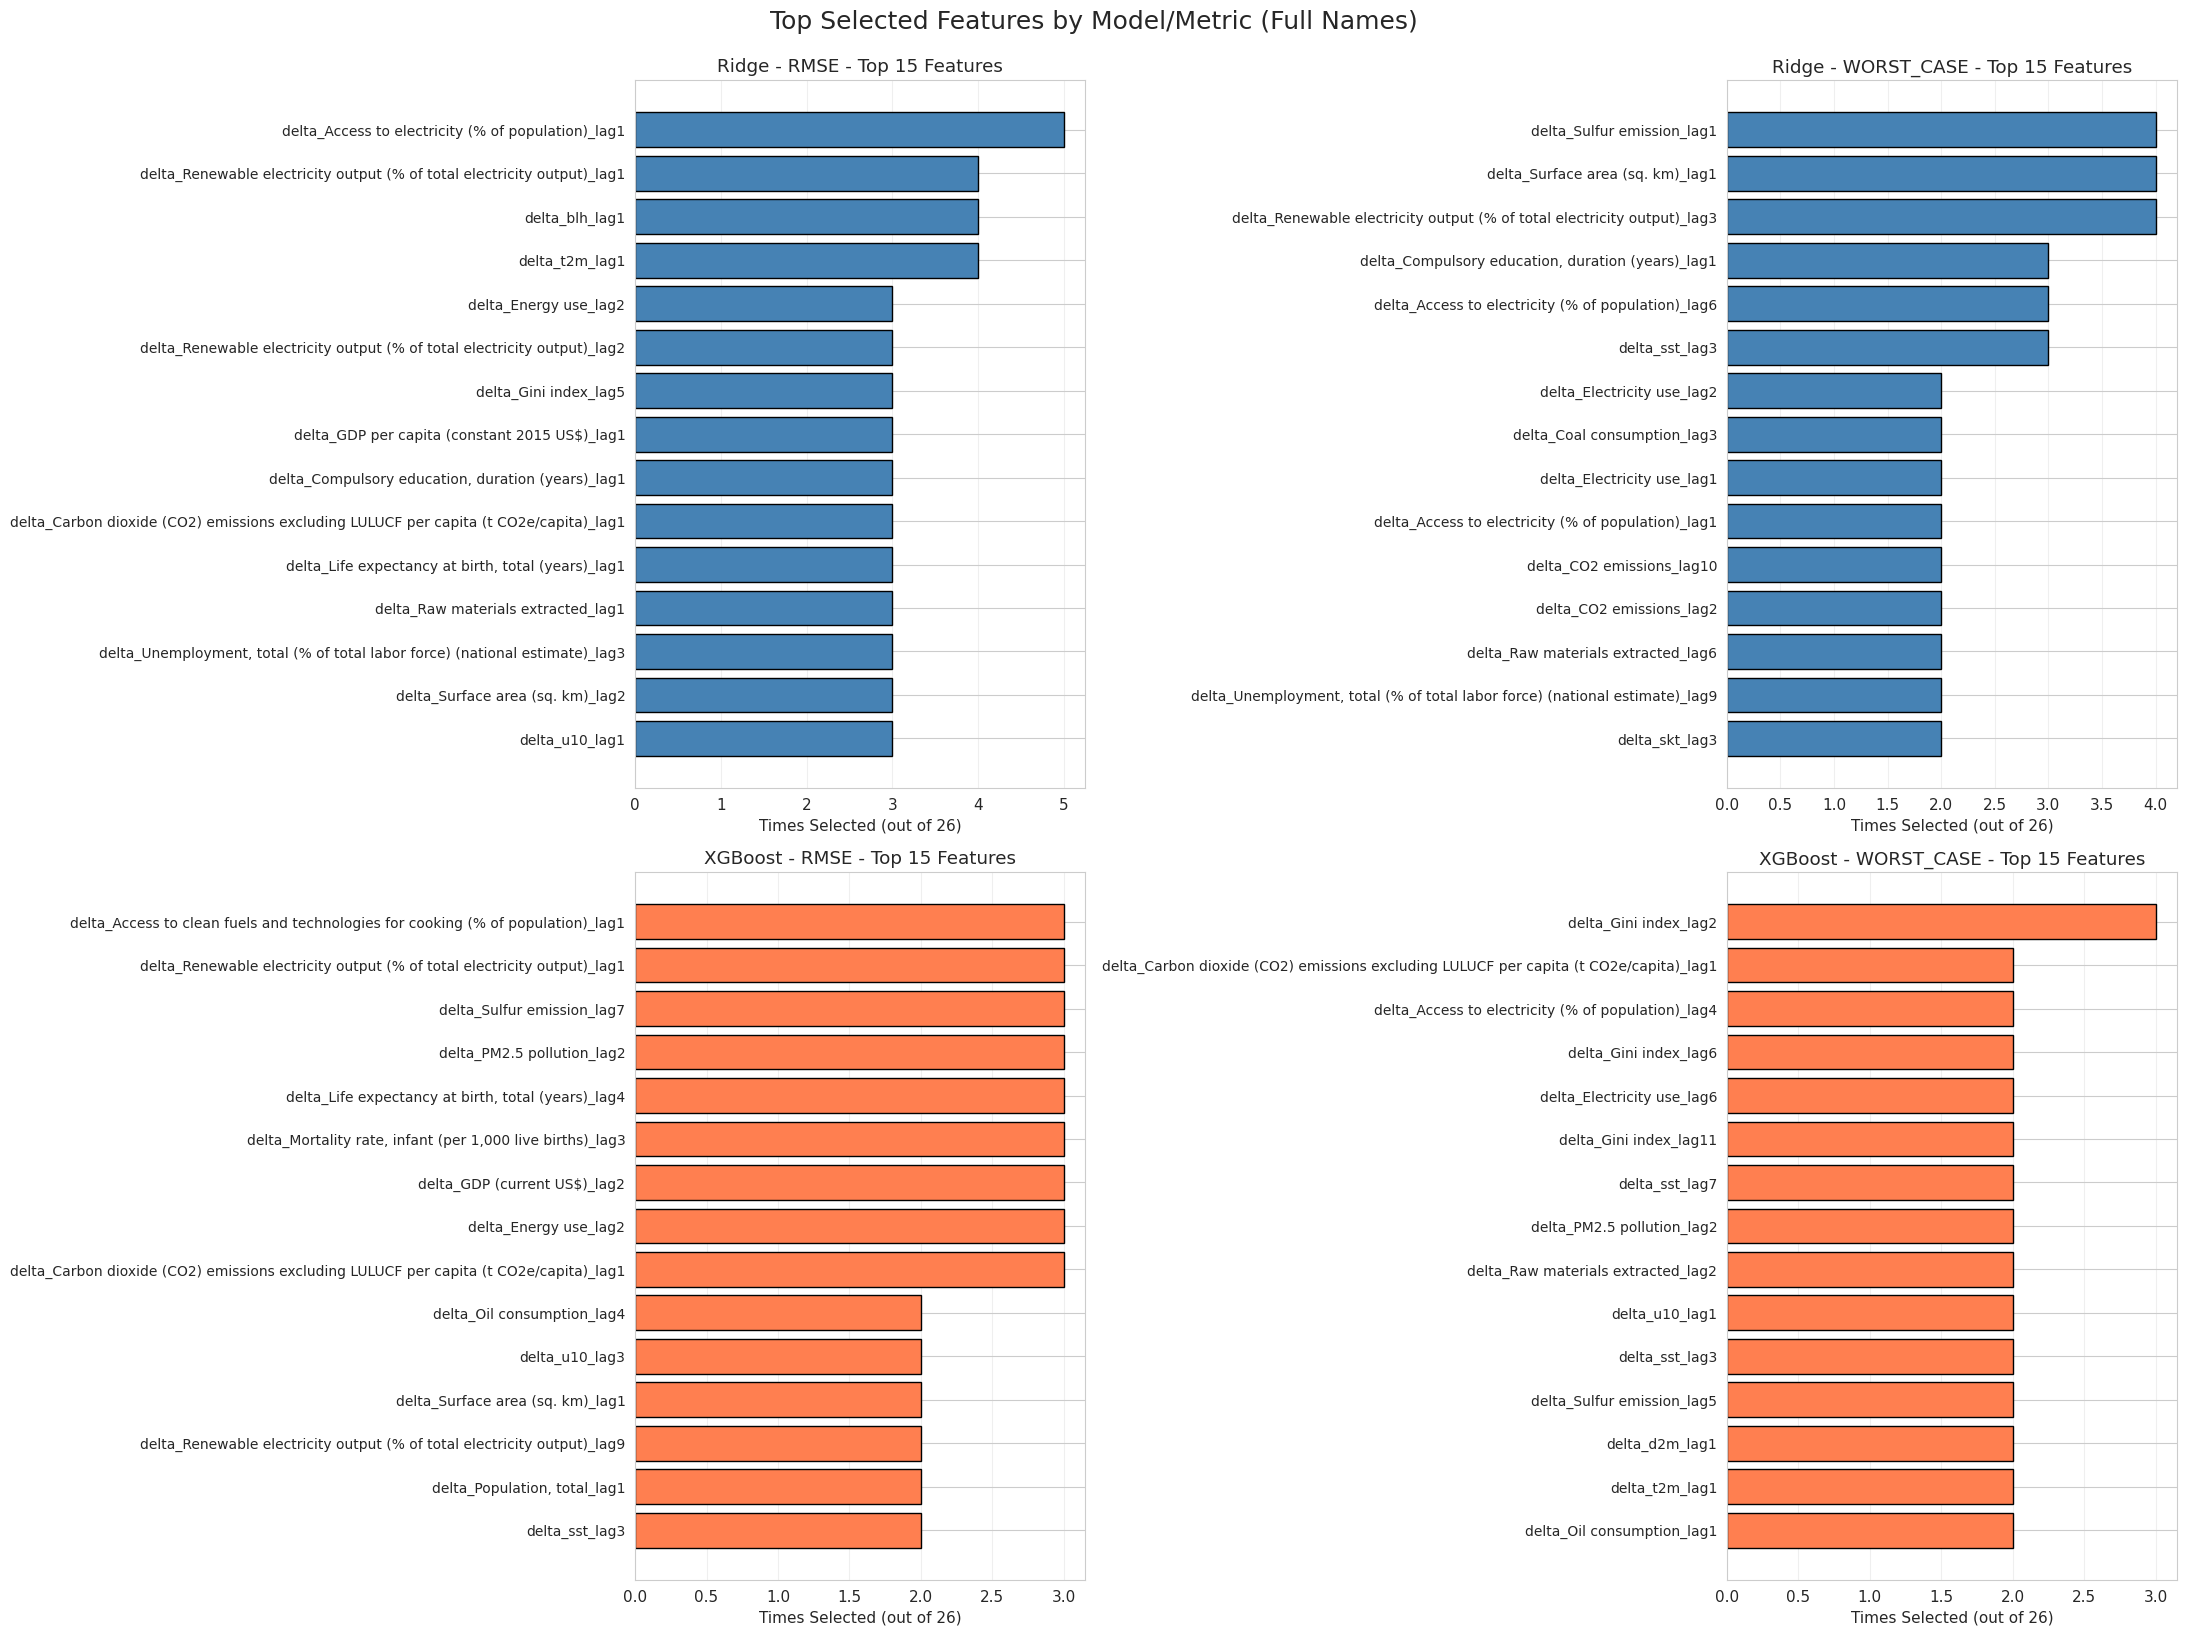

In [11]:
# Plot top selected features for each model/metric combination (4 subplots)
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
top_n = 15

combinations = [
    ("Ridge", "rmse"),
    ("Ridge", "worst_case"),
    ("XGBoost", "rmse"),
    ("XGBoost", "worst_case")
]

for idx, (model, metric) in enumerate(combinations):
    ax = axes[idx // 2, idx % 2]
    subset = features_df[(features_df['model'] == model) & (features_df['optimized_for'] == metric)]
    counts = subset.groupby('feature').size().sort_values(ascending=False).head(top_n)
    n_sel = len(fs_summary[(fs_summary['model'] == model) & (fs_summary['optimize_metric'] == metric)])
    
    bars = ax.barh(range(len(counts)), counts.values, color='steelblue' if model == 'Ridge' else 'coral', edgecolor='black')
    ax.set_yticks(range(len(counts)))
    # Show full feature names, not truncated
    ax.set_yticklabels(list(counts.index), fontsize=10)
    ax.set_xlabel(f'Times Selected (out of {n_sel})')
    ax.set_title(f'{model} - {metric.upper()} - Top {top_n} Features')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    # Print all feature names for this subplot
    print(f"\n{model} - {metric.upper()} - Top {top_n} Features:")
    for i, (feat, count) in enumerate(counts.items(), 1):
        pct = 100 * count / n_sel if n_sel else 0
        print(f"{i:2d}. {feat}: {count} times ({pct:.1f}%)")

plt.tight_layout()
plt.suptitle('Top Selected Features by Model/Metric (Full Names)', y=1.02, fontsize=18)
plt.show()

## 5. Feature Family Analysis

In [12]:
# Feature family analysis - extract base feature name (remove delta_ prefix and _lagN suffix)
def extract_family(feature_name):
    """Extract the base feature family from a delta feature name."""
    name = feature_name
    if name.startswith('delta_'):
        name = name[6:]
    if '_lag' in name:
        name = name.rsplit('_lag', 1)[0]
    return name

features_df['family'] = features_df['feature'].apply(extract_family)
family_counts = features_df.groupby('family').size().sort_values(ascending=False)

print("=" * 80)
print(f"TOP 20 FEATURE FAMILIES")
print(f"(base features, ignoring lag - across {n_selections} selection runs)")
print("=" * 80)
for i, (fam, count) in enumerate(family_counts.head(20).items(), 1):
    pct = 100 * count / n_selections
    print(f"{i:2d}. {fam}: {count} times ({pct:.1f}%)")

TOP 20 FEATURE FAMILIES
(base features, ignoring lag - across 104 selection runs)
 1. Gini index: 39 times (37.5%)
 2. Raw materials extracted: 37 times (35.6%)
 3. Unemployment, total (% of total labor force) (national estimate): 34 times (32.7%)
 4. u10: 32 times (30.8%)
 5. Renewable electricity output (% of total electricity output): 31 times (29.8%)
 6. Mortality rate, infant (per 1,000 live births): 31 times (29.8%)
 7. blh: 30 times (28.8%)
 8. Sulfur emission: 29 times (27.9%)
 9. CO2 emissions: 28 times (26.9%)
10. Surface area (sq. km): 28 times (26.9%)
11. Life expectancy at birth, total (years): 28 times (26.9%)
12. sst: 27 times (26.0%)
13. Energy use: 27 times (26.0%)
14. Access to electricity (% of population): 25 times (24.0%)
15. GDP (current US$): 24 times (23.1%)
16. Electricity use: 23 times (22.1%)
17. t2m: 23 times (22.1%)
18. Oil consumption: 23 times (22.1%)
19. Coal consumption: 22 times (21.2%)
20. d2m: 22 times (21.2%)


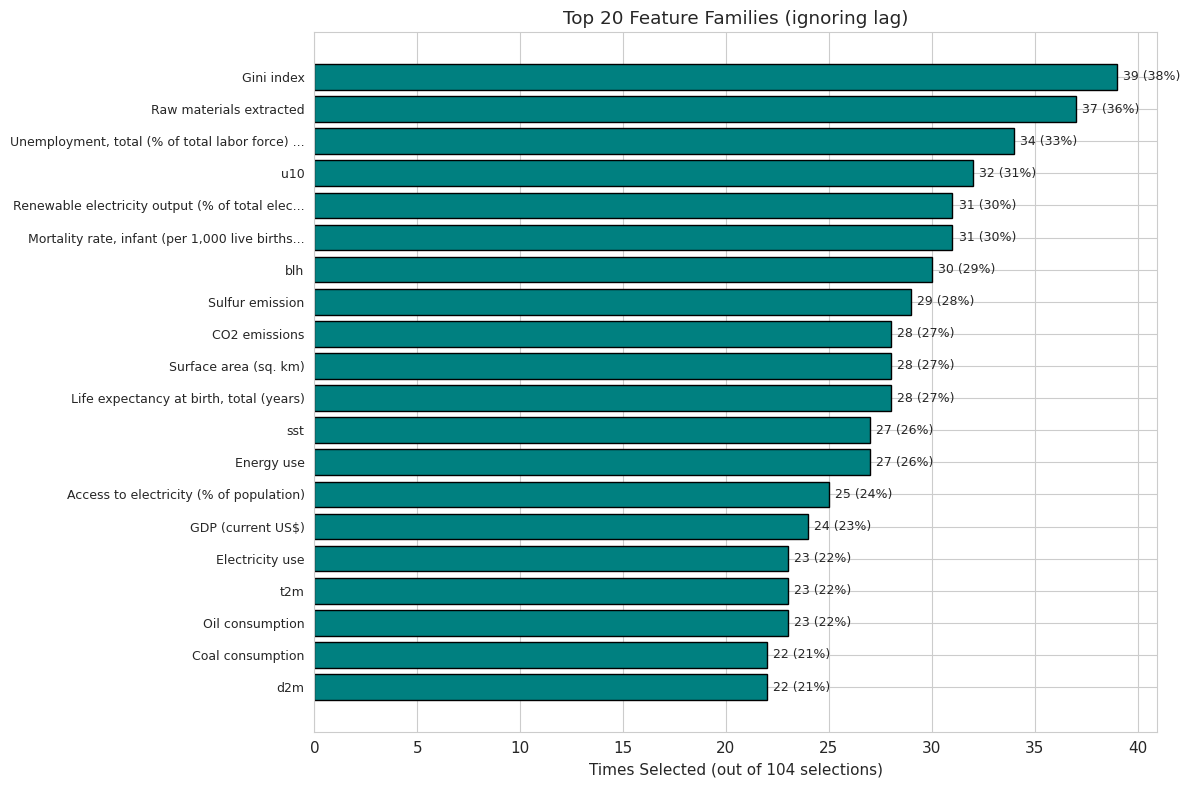

In [13]:
# Plot feature families
fig, ax = plt.subplots(figsize=(12, 8))
top_families = family_counts.head(20)
bars = ax.barh(range(len(top_families)), top_families.values, color='teal', edgecolor='black')
ax.set_yticks(range(len(top_families)))
ax.set_yticklabels([f[:45] + '...' if len(f) > 45 else f for f in top_families.index], fontsize=9)
ax.set_xlabel(f'Times Selected (out of {n_selections} selections)')
ax.set_title('Top 20 Feature Families (ignoring lag)')
ax.invert_yaxis()

for bar, count in zip(bars, top_families.values):
    pct = 100 * count / n_selections
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{count} ({pct:.0f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Feature Consistency Across Years

In [14]:
# Feature consistency: which features are selected in MOST years?
print("=" * 80)
print("FEATURE CONSISTENCY ACROSS YEARS")
print("=" * 80)

n_years = len(fs_summary['target_year'].unique())

for selection in fs_summary['selection'].unique():
    print(f"\n### {selection} ###")
    
    sel_data = fs_summary[fs_summary['selection'] == selection]
    n_years_sel = len(sel_data)
    
    # Count years each feature appears
    feature_year_counts = {}
    for _, row in sel_data.iterrows():
        for feat in row['selected_features'].split(' | '):
            feat = feat.strip()
            if feat not in feature_year_counts:
                feature_year_counts[feat] = 0
            feature_year_counts[feat] += 1
    
    # Sort by frequency
    sorted_features = sorted(feature_year_counts.items(), key=lambda x: x[1], reverse=True)
    
    # Show features appearing in at least 20% of years
    threshold = max(2, int(n_years_sel * 0.2))
    consistent_features = [(f, c) for f, c in sorted_features if c >= threshold]
    
    if consistent_features:
        print(f"  Features appearing in ≥{threshold}/{n_years_sel} years:")
        for feat, count in consistent_features[:10]:
            pct = 100 * count / n_years_sel
            feat_short = feat[:60] + '...' if len(feat) > 60 else feat
            print(f"    - {feat_short}: {count} years ({pct:.0f}%)")
    else:
        print(f"  No features appear in ≥{threshold} years (high variability)")

FEATURE CONSISTENCY ACROSS YEARS

### Ridge_rmse ###
  Features appearing in ≥5/26 years:
    - delta_Access to electricity (% of population)_lag1: 5 years (19%)

### Ridge_worst_case ###
  No features appear in ≥5 years (high variability)

### XGBoost_rmse ###
  No features appear in ≥5 years (high variability)

### XGBoost_worst_case ###
  No features appear in ≥5 years (high variability)


## 7. Lag Analysis

Analyzing which **lag values** (years before target) are consistently selected.

Total features with lag values: 719


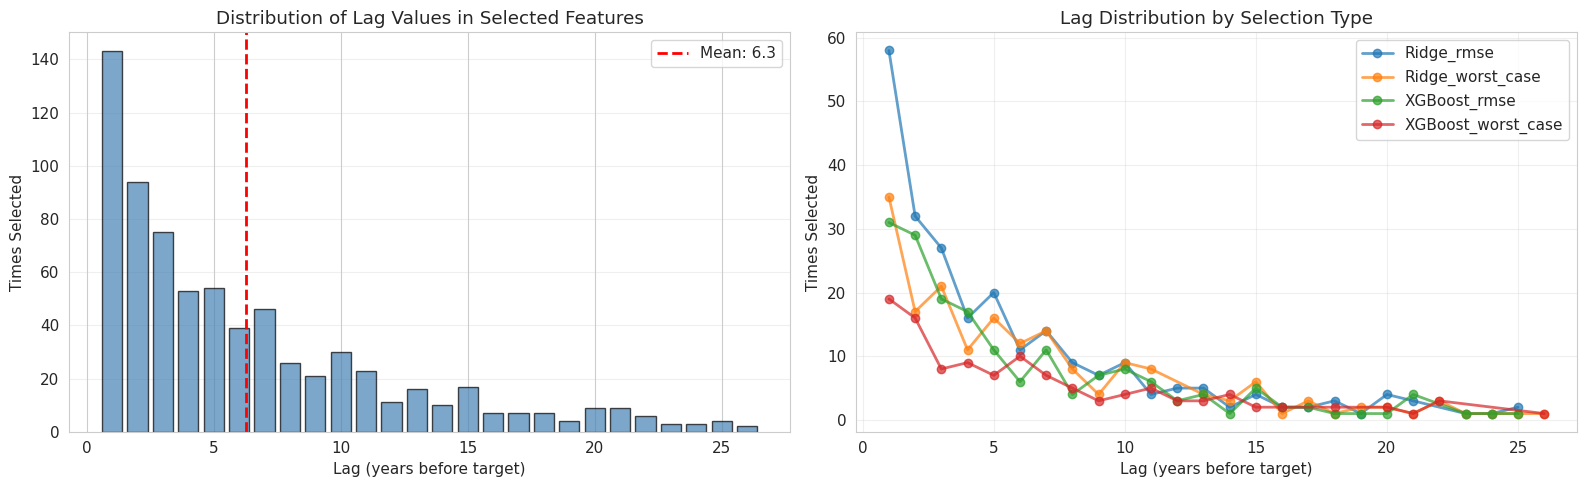


Lag Statistics:
  Mean lag:   6.3 years
  Median lag: 4.0 years
  Std dev:    5.7 years


In [15]:
# Extract lag values from features
def extract_lag(feature_name):
    """Extract the lag value from a feature name like 'delta_GDP_lag5' -> 5"""
    if '_lag' in feature_name:
        try:
            lag_str = feature_name.rsplit('_lag', 1)[1]
            return int(lag_str)
        except:
            return None
    return None

features_df['lag'] = features_df['feature'].apply(extract_lag)
features_with_lag = features_df[features_df['lag'].notna()].copy()
features_with_lag['lag'] = features_with_lag['lag'].astype(int)

print(f"Total features with lag values: {len(features_with_lag)}")

# Lag distribution
lag_counts = features_with_lag['lag'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of lag values
ax = axes[0]
ax.bar(lag_counts.index, lag_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Lag (years before target)')
ax.set_ylabel('Times Selected')
ax.set_title('Distribution of Lag Values in Selected Features')
ax.grid(axis='y', alpha=0.3)
mean_lag = features_with_lag['lag'].mean()
ax.axvline(mean_lag, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_lag:.1f}')
ax.legend()

# By selection type
ax = axes[1]
for selection in fs_summary['selection'].unique():
    parts = selection.split('_')
    model = parts[0]
    metric = '_'.join(parts[1:])
    sel_features = features_with_lag[
        (features_with_lag['model'] == model) & 
        (features_with_lag['optimized_for'] == metric)
    ]
    if len(sel_features) > 0:
        lag_dist = sel_features['lag'].value_counts().sort_index()
        ax.plot(lag_dist.index, lag_dist.values, 'o-', label=selection, alpha=0.7, linewidth=2)

ax.set_xlabel('Lag (years before target)')
ax.set_ylabel('Times Selected')
ax.set_title('Lag Distribution by Selection Type')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLag Statistics:")
print(f"  Mean lag:   {features_with_lag['lag'].mean():.1f} years")
print(f"  Median lag: {features_with_lag['lag'].median():.1f} years")
print(f"  Std dev:    {features_with_lag['lag'].std():.1f} years")

LAG RANGES ANALYSIS

Lag ranges (years before target):
  1-5 years: 419 features (58.3%)
  6-10 years: 162 features (22.5%)
  11-15 years:  77 features (10.7%)
  16-20 years:  34 features (4.7%)
  21+ years:  27 features (3.8%)


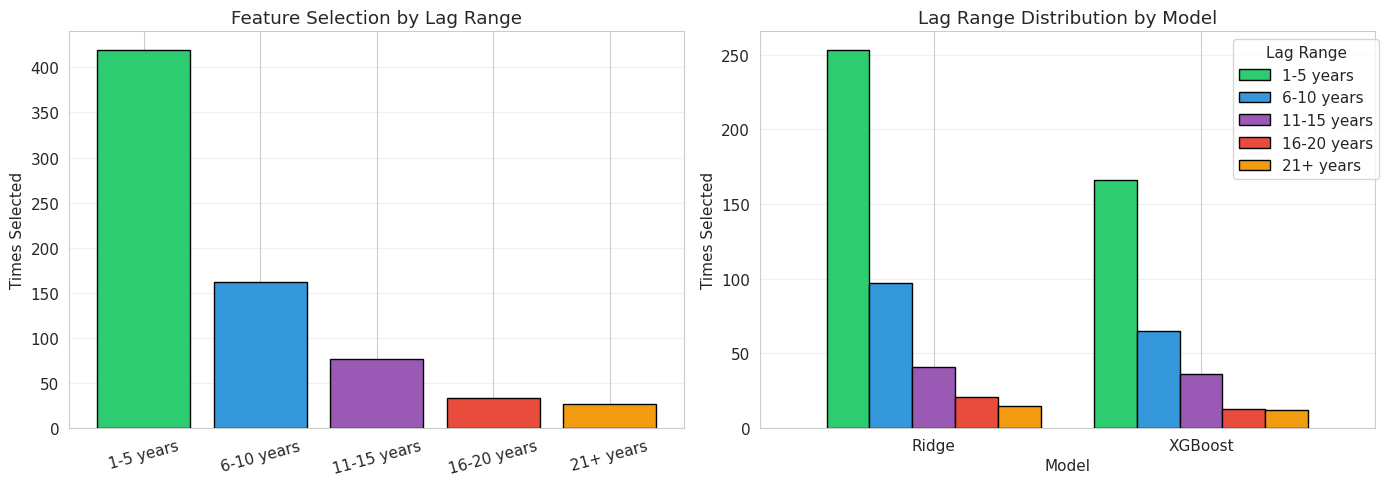

In [16]:
# Lag ranges analysis
def lag_to_range(lag):
    if lag <= 5:
        return '1-5 years'
    elif lag <= 10:
        return '6-10 years'
    elif lag <= 15:
        return '11-15 years'
    elif lag <= 20:
        return '16-20 years'
    else:
        return '21+ years'

features_with_lag['lag_range'] = features_with_lag['lag'].apply(lag_to_range)
range_order = ['1-5 years', '6-10 years', '11-15 years', '16-20 years', '21+ years']
range_counts = features_with_lag['lag_range'].value_counts().reindex(range_order)

print("=" * 80)
print("LAG RANGES ANALYSIS")
print("=" * 80)

print("\nLag ranges (years before target):")
for range_name, count in range_counts.items():
    if pd.notna(count):
        pct = 100 * count / len(features_with_lag)
        print(f"  {range_name}: {int(count):3d} features ({pct:.1f}%)")

# Plot by range
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12']
valid_counts = range_counts.dropna()
bars = ax.bar(range(len(valid_counts)), valid_counts.values, color=colors[:len(valid_counts)], edgecolor='black')
ax.set_xticks(range(len(valid_counts)))
ax.set_xticklabels(valid_counts.index, rotation=15)
ax.set_ylabel('Times Selected')
ax.set_title('Feature Selection by Lag Range')
ax.grid(axis='y', alpha=0.3)

# By model
ax = axes[1]
range_by_model = features_with_lag.groupby(['model', 'lag_range']).size().unstack(fill_value=0)
range_by_model = range_by_model.reindex(columns=[r for r in range_order if r in range_by_model.columns])
range_by_model.plot(kind='bar', ax=ax, color=colors[:len(range_by_model.columns)], edgecolor='black', width=0.8)
ax.set_xlabel('Model')
ax.set_ylabel('Times Selected')
ax.set_title('Lag Range Distribution by Model')
ax.legend(title='Lag Range', bbox_to_anchor=(1.02, 1))
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Feature Selection History (Step-by-Step Progress)

In [17]:
# Combine all history files into one dataframe
all_histories = []
for key, history in fs_histories.items():
    all_histories.append(history)

combined_history = pd.concat(all_histories, ignore_index=True)

print(f"Total selection steps: {len(combined_history)}")
print(f"Columns: {combined_history.columns.tolist()}")
display(combined_history.head())

Total selection steps: 719
Columns: ['step', 'selected_feature', 'family', 'n_selected', 'n_remaining', 'rmse', 'worst_case', 'year', 'model', 'metric']


,step,selected_feature,family,n_selected,n_remaining,rmse,worst_case,year,model,metric
0,1,delta_u10_lag1,delta_u10,1,32,1.964227,4.844763,1991,Ridge,rmse
1,2,delta_v10_lag1,delta_v10,2,31,1.874295,5.390691,1991,Ridge,rmse
2,3,"delta_Mortality rate, infant (per 1,000 live b...","delta_Mortality rate, infant (per 1,000 live b...",3,30,1.849253,5.510689,1991,Ridge,rmse
3,4,delta_Renewable electricity output (% of total...,delta_Renewable electricity output (% of total...,4,29,1.821489,5.569137,1991,Ridge,rmse
4,5,delta_Natural gas production_y_lag1,delta_Natural gas production_y,5,28,1.817734,5.447827,1991,Ridge,rmse


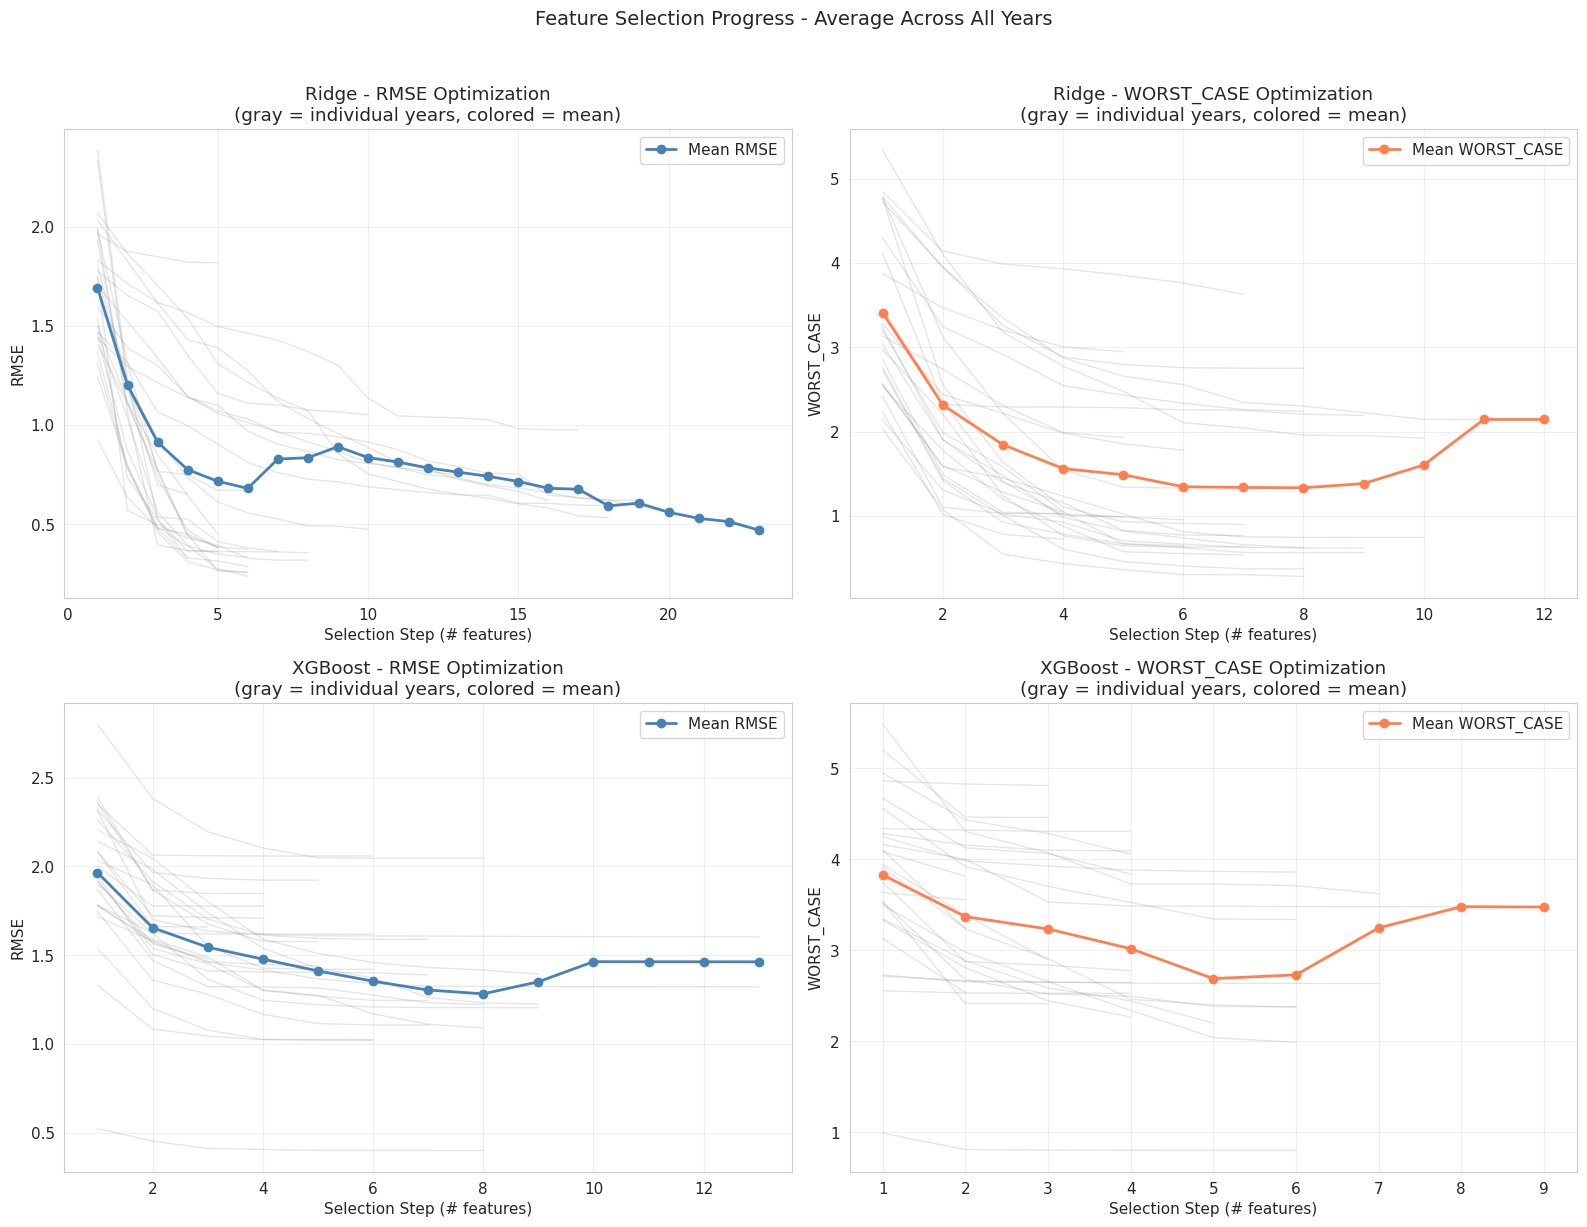

In [18]:
# Plot average feature selection progress across all years
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (model, metric) in enumerate([('Ridge', 'rmse'), ('Ridge', 'worst_case'), 
                                        ('XGBoost', 'rmse'), ('XGBoost', 'worst_case')]):
    ax = axes[idx // 2, idx % 2]
    
    # Filter data for this model/metric combination
    data = combined_history[(combined_history['model'] == model) & (combined_history['metric'] == metric)]
    
    if len(data) > 0:
        # Plot individual years with low alpha
        for year in data['year'].unique():
            year_data = data[data['year'] == year]
            target_col = 'rmse' if metric == 'rmse' else 'worst_case'
            ax.plot(year_data['step'], year_data[target_col], alpha=0.2, color='gray', linewidth=1)
        
        # Plot average across years
        avg_by_step = data.groupby('step').agg({'rmse': 'mean', 'worst_case': 'mean'}).reset_index()
        target_col = 'rmse' if metric == 'rmse' else 'worst_case'
        
        ax.plot(avg_by_step['step'], avg_by_step[target_col], 'o-', 
                color='steelblue' if metric == 'rmse' else 'coral', 
                linewidth=2, markersize=6, label=f'Mean {target_col.upper()}')
        
        ax.set_xlabel('Selection Step (# features)')
        ax.set_ylabel(target_col.upper())
        ax.set_title(f'{model} - {metric.upper()} Optimization\n(gray = individual years, colored = mean)')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.suptitle('Feature Selection Progress - Average Across All Years', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# First features added during selection (most important features)
print("=" * 80)
print("FIRST FEATURES SELECTED (Most Important)")
print("Features selected at step 1 across all years")
print("=" * 80)

first_step_features = combined_history[combined_history['step'] == 1]
first_feature_counts = first_step_features.groupby('selected_feature').size().sort_values(ascending=False)

print(f"\nTop 15 first-selected features:")
for i, (feat, count) in enumerate(first_feature_counts.head(15).items(), 1):
    pct = 100 * count / len(first_step_features)
    feat_short = feat[:60] + '...' if len(feat) > 60 else feat
    print(f"{i:2d}. {feat_short}: {count} times ({pct:.1f}%)")

FIRST FEATURES SELECTED (Most Important)
Features selected at step 1 across all years

Top 15 first-selected features:
 1. delta_Gini index_lag11: 5 times (4.8%)
 2. delta_Gini index_lag7: 4 times (3.8%)
 3. delta_CO2 emissions_lag2: 4 times (3.8%)
 4. delta_u10_lag1: 4 times (3.8%)
 5. delta_u10_lag3: 4 times (3.8%)
 6. delta_blh_lag1: 3 times (2.9%)
 7. delta_Oil consumption_lag21: 3 times (2.9%)
 8. delta_Mortality rate, infant (per 1,000 live births)_lag2: 3 times (2.9%)
 9. delta_Mortality rate, infant (per 1,000 live births)_lag4: 3 times (2.9%)
10. delta_Gini index_lag6: 3 times (2.9%)
11. delta_CO2 emissions_lag1: 2 times (1.9%)
12. delta_u10_lag2: 2 times (1.9%)
13. delta_Mortality rate, infant (per 1,000 live births)_lag18: 2 times (1.9%)
14. delta_Surface area (sq. km)_lag14: 2 times (1.9%)
15. delta_blh_lag2: 2 times (1.9%)


In [20]:
# Feature family importance by selection step
# Earlier steps = more important features
combined_history['family'] = combined_history['selected_feature'].apply(extract_family)

# Average step when each family is first selected
family_avg_step = combined_history.groupby('family')['step'].mean().sort_values()

print("=" * 80)
print("FEATURE FAMILIES BY AVERAGE SELECTION STEP")
print("(Lower step = selected earlier = more important)")
print("=" * 80)

print("\nTop 15 earliest-selected families:")
for i, (fam, avg_step) in enumerate(family_avg_step.head(15).items(), 1):
    count = (combined_history['family'] == fam).sum()
    fam_short = fam[:50] + '...' if len(fam) > 50 else fam
    print(f"{i:2d}. {fam_short}: avg step {avg_step:.1f} (selected {count} times)")

FEATURE FAMILIES BY AVERAGE SELECTION STEP
(Lower step = selected earlier = more important)

Top 15 earliest-selected families:
 1. u10: avg step 3.0 (selected 32 times)
 2. Mortality rate, infant (per 1,000 live births): avg step 3.1 (selected 31 times)
 3. GDP (current US$): avg step 3.3 (selected 24 times)
 4. Gini index: avg step 3.5 (selected 39 times)
 5. CO2 emissions: avg step 3.9 (selected 28 times)
 6. sst: avg step 4.3 (selected 27 times)
 7. blh: avg step 4.5 (selected 30 times)
 8. Coal consumption: avg step 4.5 (selected 22 times)
 9. Life expectancy at birth, total (years): avg step 4.6 (selected 28 times)
10. People using at least basic sanitation services (%...: avg step 4.7 (selected 3 times)
11. Access to clean fuels and technologies for cooking...: avg step 4.7 (selected 6 times)
12. v10: avg step 4.8 (selected 19 times)
13. Unemployment, total (% of total labor force) (nati...: avg step 4.8 (selected 34 times)
14. GDP per capita (constant 2015 US$): avg step 4.9 (s

## 9. Feature Selection Heatmap by Year

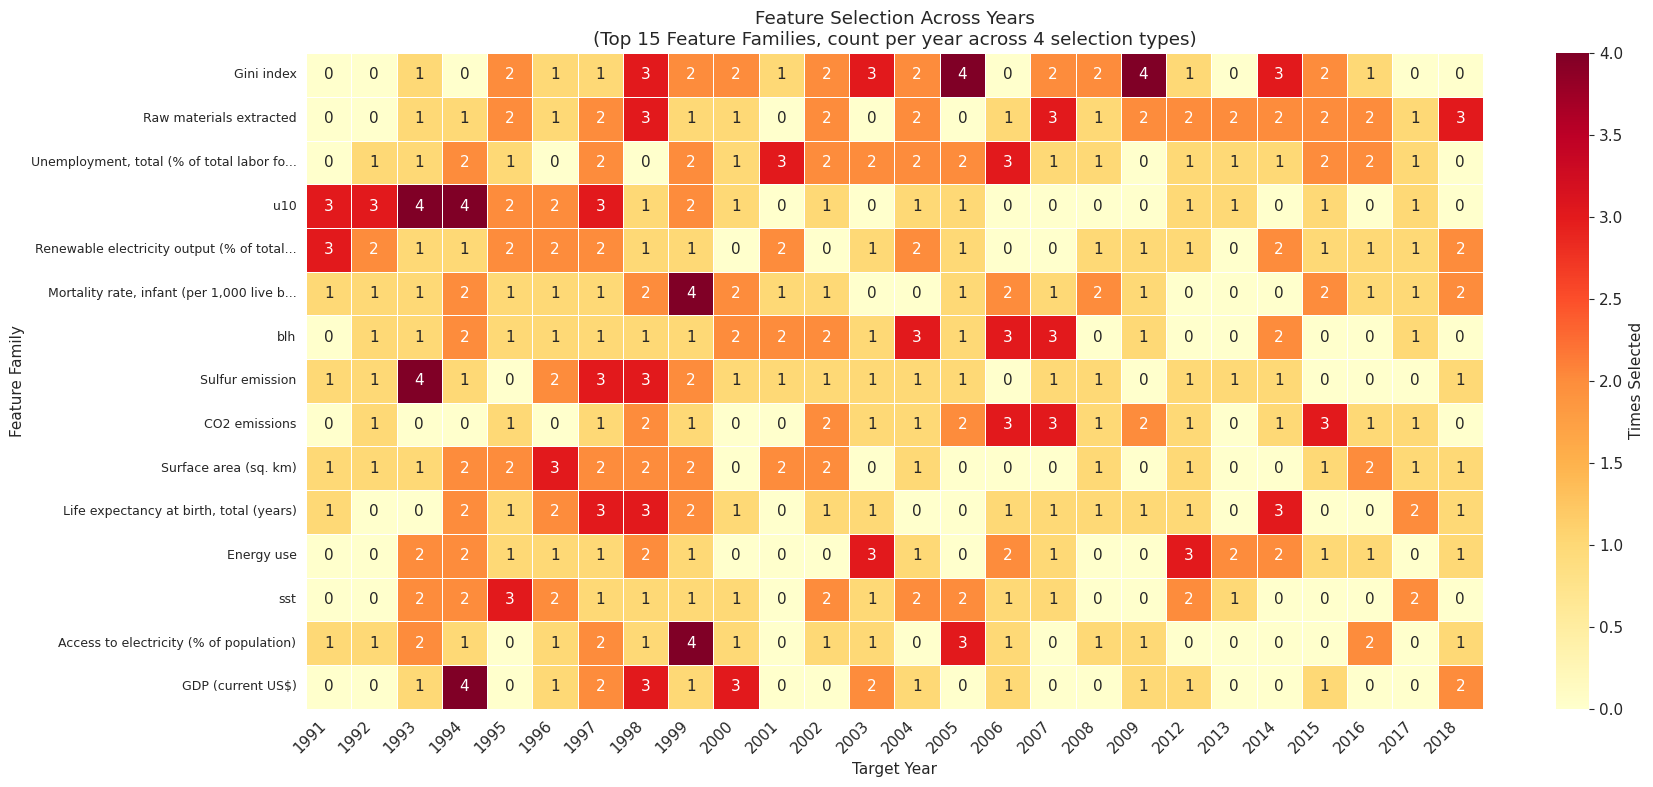

In [21]:
# Create heatmap of feature selection across years
# Get top feature families
top_families_list = family_counts.head(15).index.tolist()
years = sorted(fs_summary['target_year'].unique())

# Create matrix: family x year (count of selections)
family_year_matrix = features_df[features_df['family'].isin(top_families_list)].groupby(
    ['family', 'year']
).size().unstack(fill_value=0)

# Reorder rows by total count
row_order = family_year_matrix.sum(axis=1).sort_values(ascending=False).index
family_year_matrix = family_year_matrix.loc[row_order]

# Plot heatmap
fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(family_year_matrix, cmap='YlOrRd', annot=True, fmt='d', ax=ax, 
            cbar_kws={'label': 'Times Selected'}, linewidths=0.5)
ax.set_xlabel('Target Year')
ax.set_ylabel('Feature Family')
ax.set_title('Feature Selection Across Years\n(Top 15 Feature Families, count per year across 4 selection types)')

# Rotate y-axis labels
ax.set_yticklabels([f[:40] + '...' if len(str(f)) > 40 else f for f in family_year_matrix.index], 
                   fontsize=9, rotation=0)
ax.set_xticklabels(family_year_matrix.columns.astype(int), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 10. Lag Patterns by Feature Family

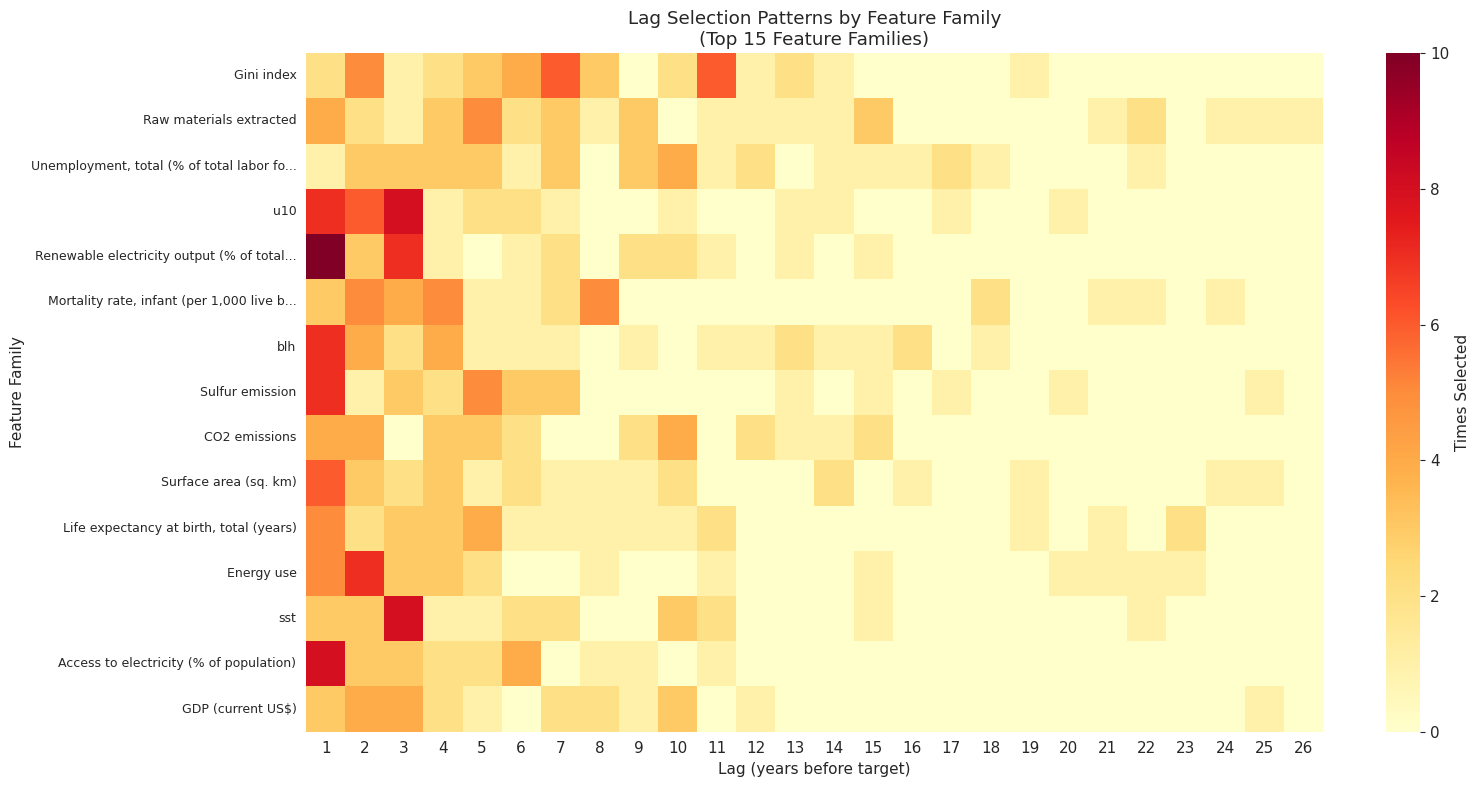


PREFERRED LAG BY FEATURE FAMILY
  Gini index: mean=7.3, mode=7, n=39
  Raw materials extracted: mean=9.5, mode=5, n=37
  Unemployment, total (% of total labor fo...: mean=8.6, mode=10, n=34
  u10: mean=4.7, mode=3, n=32
  Renewable electricity output (% of total...: mean=4.5, mode=1, n=31
  Mortality rate, infant (per 1,000 live b...: mean=6.9, mode=2, n=31
  blh: mean=6.4, mode=1, n=30
  Sulfur emission: mean=6.2, mode=1, n=29
  CO2 emissions: mean=6.8, mode=1, n=28
  Surface area (sq. km): mean=7.2, mode=1, n=28


In [22]:
# Lag heatmap by feature family
lag_family_matrix = features_with_lag[features_with_lag['family'].isin(top_families_list)].groupby(
    ['family', 'lag']
).size().unstack(fill_value=0)

# Reorder rows by total count
row_order = lag_family_matrix.sum(axis=1).sort_values(ascending=False).index
lag_family_matrix = lag_family_matrix.loc[row_order]

# Plot heatmap
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(lag_family_matrix, cmap='YlOrRd', annot=False, ax=ax, 
            cbar_kws={'label': 'Times Selected'})
ax.set_xlabel('Lag (years before target)')
ax.set_ylabel('Feature Family')
ax.set_title('Lag Selection Patterns by Feature Family\n(Top 15 Feature Families)')

ax.set_yticklabels([f[:40] + '...' if len(str(f)) > 40 else f for f in lag_family_matrix.index], 
                   fontsize=9, rotation=0)

plt.tight_layout()
plt.show()

# Preferred lag by feature family
print("\n" + "=" * 80)
print("PREFERRED LAG BY FEATURE FAMILY")
print("=" * 80)

for family in top_families_list[:10]:
    family_data = features_with_lag[features_with_lag['family'] == family]
    if len(family_data) > 0:
        mean_lag = family_data['lag'].mean()
        mode_lag = family_data['lag'].mode().iloc[0] if len(family_data['lag'].mode()) > 0 else None
        count = len(family_data)
        family_short = family[:40] + '...' if len(family) > 40 else family
        print(f"  {family_short}: mean={mean_lag:.1f}, mode={mode_lag}, n={count}")

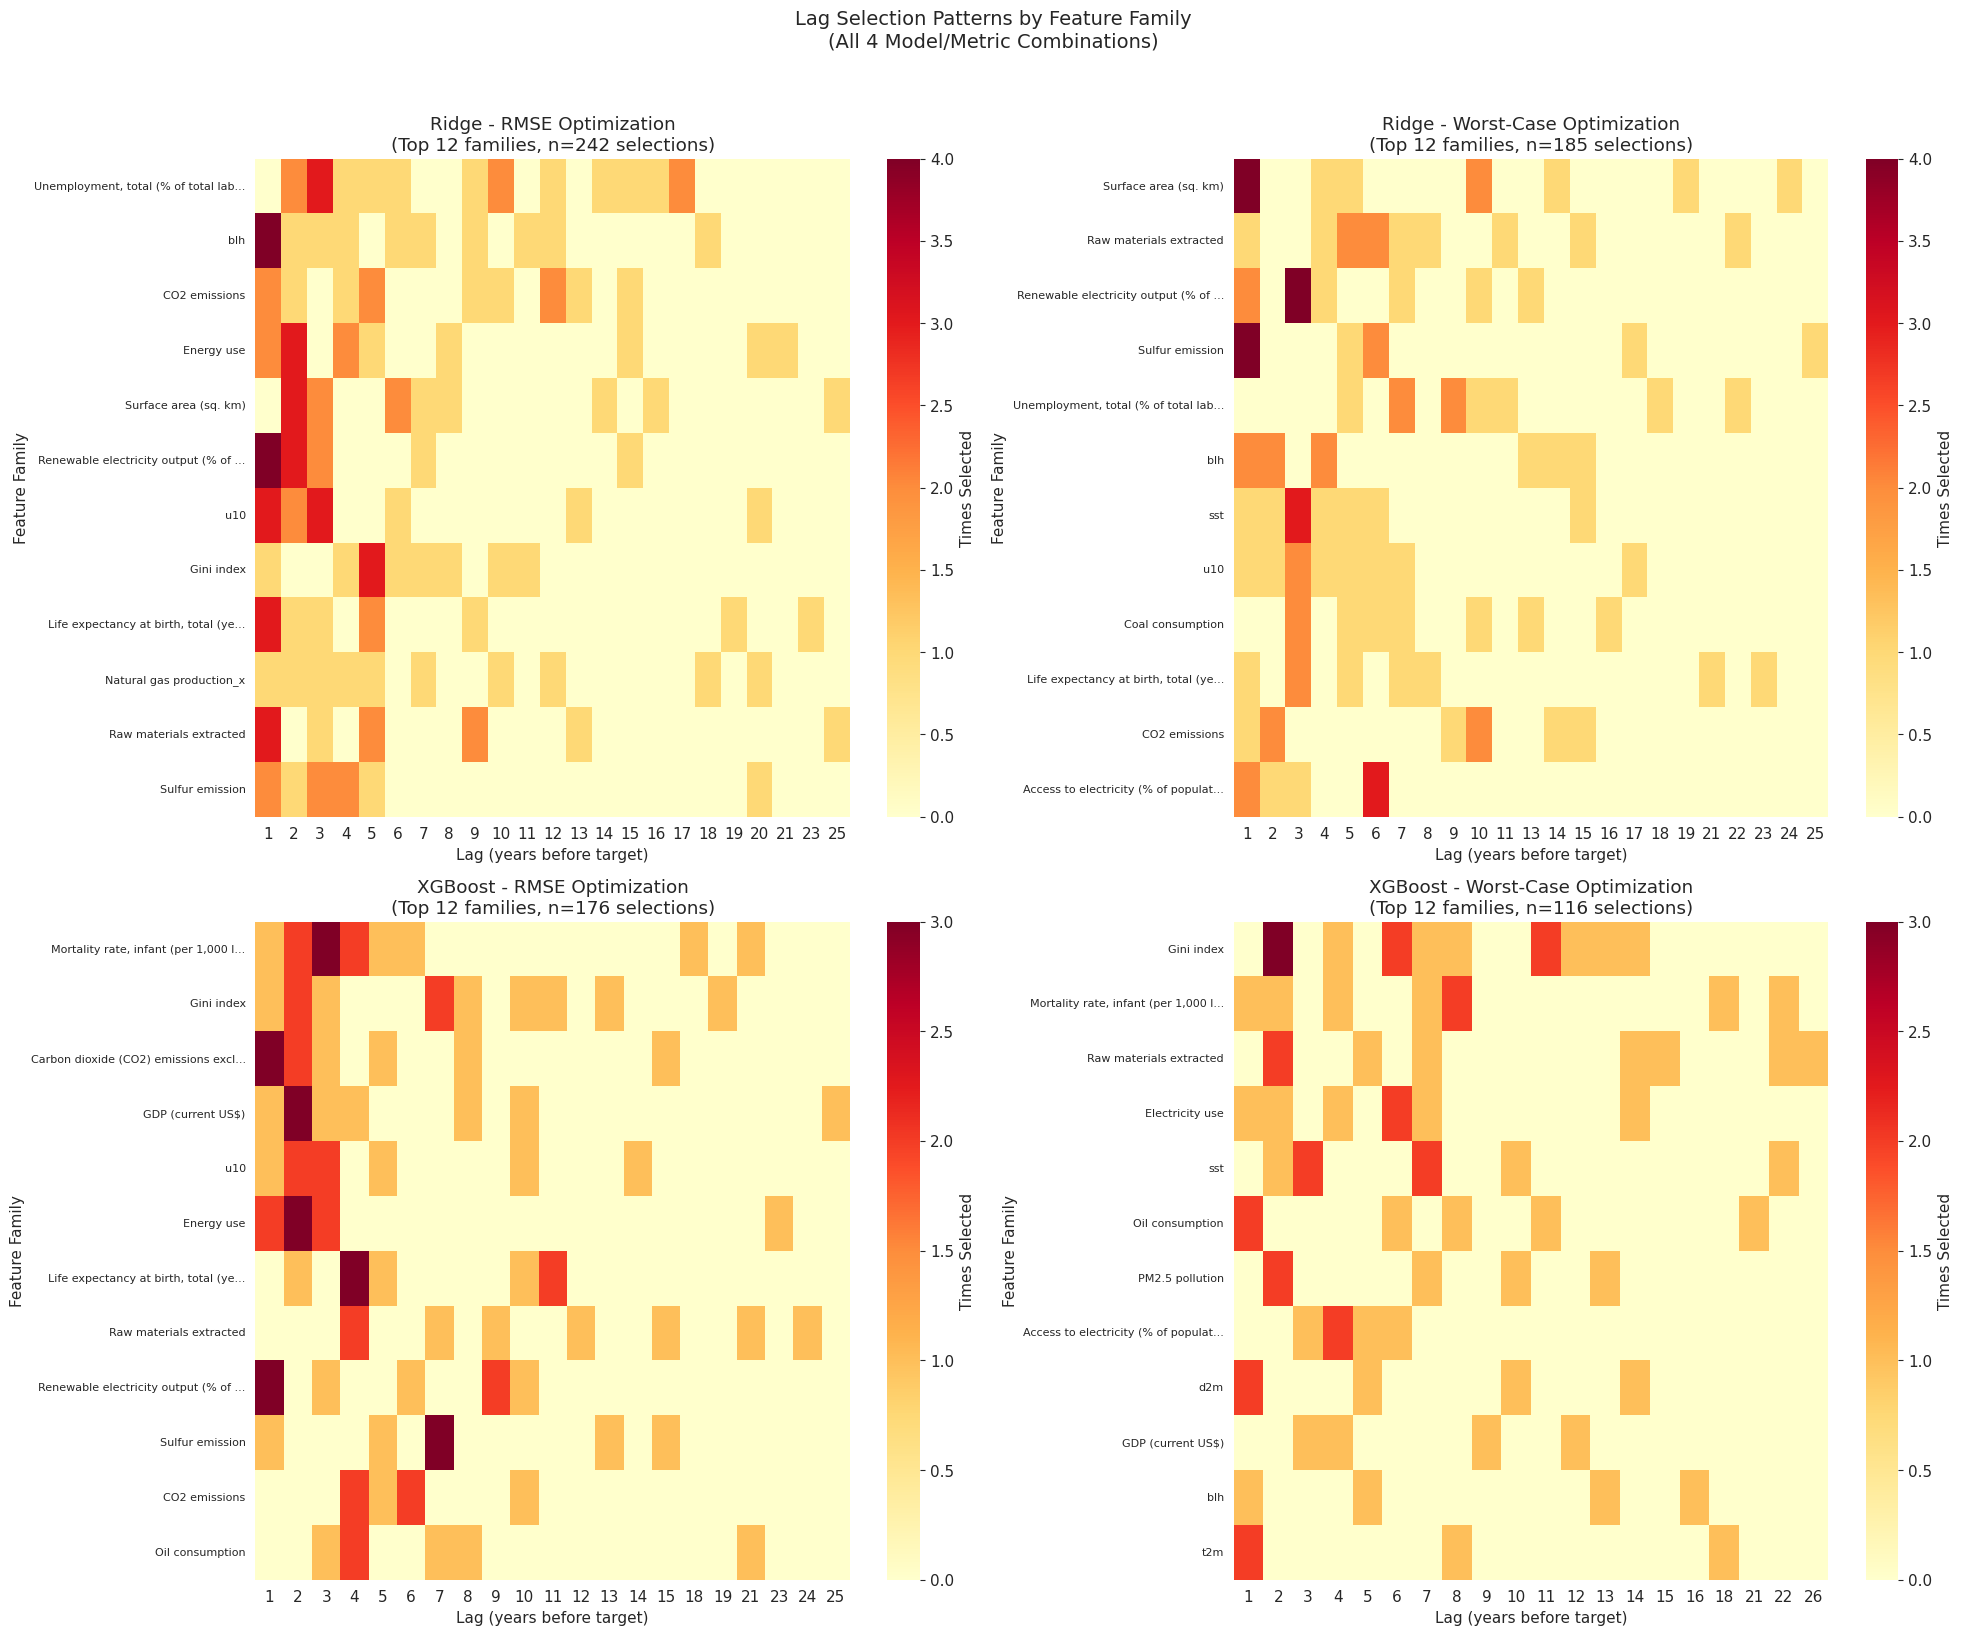


PREFERRED LAG BY FEATURE FAMILY - ALL CONFIGURATIONS

### Ridge - RMSE Optimization ###
  Total features selected: 242
  Mean lag: 5.8 years
  Mode lag: 1 years

  Top 5 families with preferred lags:
    - Unemployment, total (% of total lab...: mean=8.7, mode=3, n=17
    - blh: mean=5.8, mode=1, n=13
    - CO2 emissions: mean=7.4, mode=1, n=12
    - Energy use: mean=7.1, mode=2, n=12
    - Surface area (sq. km): mean=7.8, mode=2, n=12

### Ridge - Worst-Case Optimization ###
  Total features selected: 185
  Mean lag: 6.7 years
  Mode lag: 1 years

  Top 5 families with preferred lags:
    - Surface area (sq. km): mean=8.2, mode=1, n=11
    - Raw materials extracted: mean=8.2, mode=5, n=11
    - Renewable electricity output (% of ...: mean=4.8, mode=3, n=10
    - blh: mean=6.2, mode=1, n=9
    - Sulfur emission: mean=7.0, mode=1, n=9

### XGBoost - RMSE Optimization ###
  Total features selected: 176
  Mean lag: 6.1 years
  Mode lag: 1 years

  Top 5 families with preferred lags:
    

In [23]:
# Lag patterns by feature family for all 4 model/metric combinations
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

selection_configs = [
    ('Ridge', 'rmse', 'Ridge - RMSE Optimization'),
    ('Ridge', 'worst_case', 'Ridge - Worst-Case Optimization'),
    ('XGBoost', 'rmse', 'XGBoost - RMSE Optimization'),
    ('XGBoost', 'worst_case', 'XGBoost - Worst-Case Optimization')
]

for idx, (model, metric, title) in enumerate(selection_configs):
    ax = axes[idx // 2, idx % 2]
    
    # Filter features for this model/metric
    model_metric_features = features_with_lag[
        (features_with_lag['model'] == model) & 
        (features_with_lag['optimized_for'] == metric)
    ]
    
    # Get top families for this specific selection
    model_metric_family_counts = model_metric_features.groupby('family').size().sort_values(ascending=False)
    top_families_for_model = model_metric_family_counts.head(12).index.tolist()
    
    if len(model_metric_features) > 0 and len(top_families_for_model) > 0:
        # Create lag-family matrix for this model/metric
        lag_family_data = model_metric_features[model_metric_features['family'].isin(top_families_for_model)]
        lag_family_matrix_mm = lag_family_data.groupby(['family', 'lag']).size().unstack(fill_value=0)
        
        # Reorder rows by total count
        row_order_mm = lag_family_matrix_mm.sum(axis=1).sort_values(ascending=False).index
        lag_family_matrix_mm = lag_family_matrix_mm.loc[row_order_mm]
        
        # Plot heatmap
        sns.heatmap(lag_family_matrix_mm, cmap='YlOrRd', annot=False, ax=ax, 
                    cbar_kws={'label': 'Times Selected'})
        ax.set_xlabel('Lag (years before target)')
        ax.set_ylabel('Feature Family')
        ax.set_title(f'{title}\n(Top 12 families, n={len(model_metric_features)} selections)')
        
        # Truncate long family names
        ax.set_yticklabels([f[:35] + '...' if len(str(f)) > 35 else f 
                           for f in lag_family_matrix_mm.index], fontsize=8, rotation=0)
    else:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', fontsize=12)
        ax.set_title(title)

plt.suptitle('Lag Selection Patterns by Feature Family\n(All 4 Model/Metric Combinations)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics for each model/metric
print("\n" + "=" * 80)
print("PREFERRED LAG BY FEATURE FAMILY - ALL CONFIGURATIONS")
print("=" * 80)

for model, metric, title in selection_configs:
    print(f"\n### {title} ###")
    
    model_metric_features = features_with_lag[
        (features_with_lag['model'] == model) & 
        (features_with_lag['optimized_for'] == metric)
    ]
    
    if len(model_metric_features) > 0:
        print(f"  Total features selected: {len(model_metric_features)}")
        print(f"  Mean lag: {model_metric_features['lag'].mean():.1f} years")
        print(f"  Mode lag: {model_metric_features['lag'].mode().iloc[0]} years")
        
        # Top 5 families for this config
        print(f"\n  Top 5 families with preferred lags:")
        model_metric_family_counts = model_metric_features.groupby('family').size().sort_values(ascending=False)
        
        for family in model_metric_family_counts.head(5).index:
            family_data = model_metric_features[model_metric_features['family'] == family]
            mean_lag = family_data['lag'].mean()
            mode_lag = family_data['lag'].mode().iloc[0] if len(family_data['lag'].mode()) > 0 else None
            count = len(family_data)
            family_short = family[:35] + '...' if len(family) > 35 else family
            print(f"    - {family_short}: mean={mean_lag:.1f}, mode={mode_lag}, n={count}")

LAG ANALYSIS - ONLY YEARS WITH ≥5 LAGS AVAILABLE
Years included: [np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
(21 years out of 26 total)
Features after filtering: 269 (from 719 total)


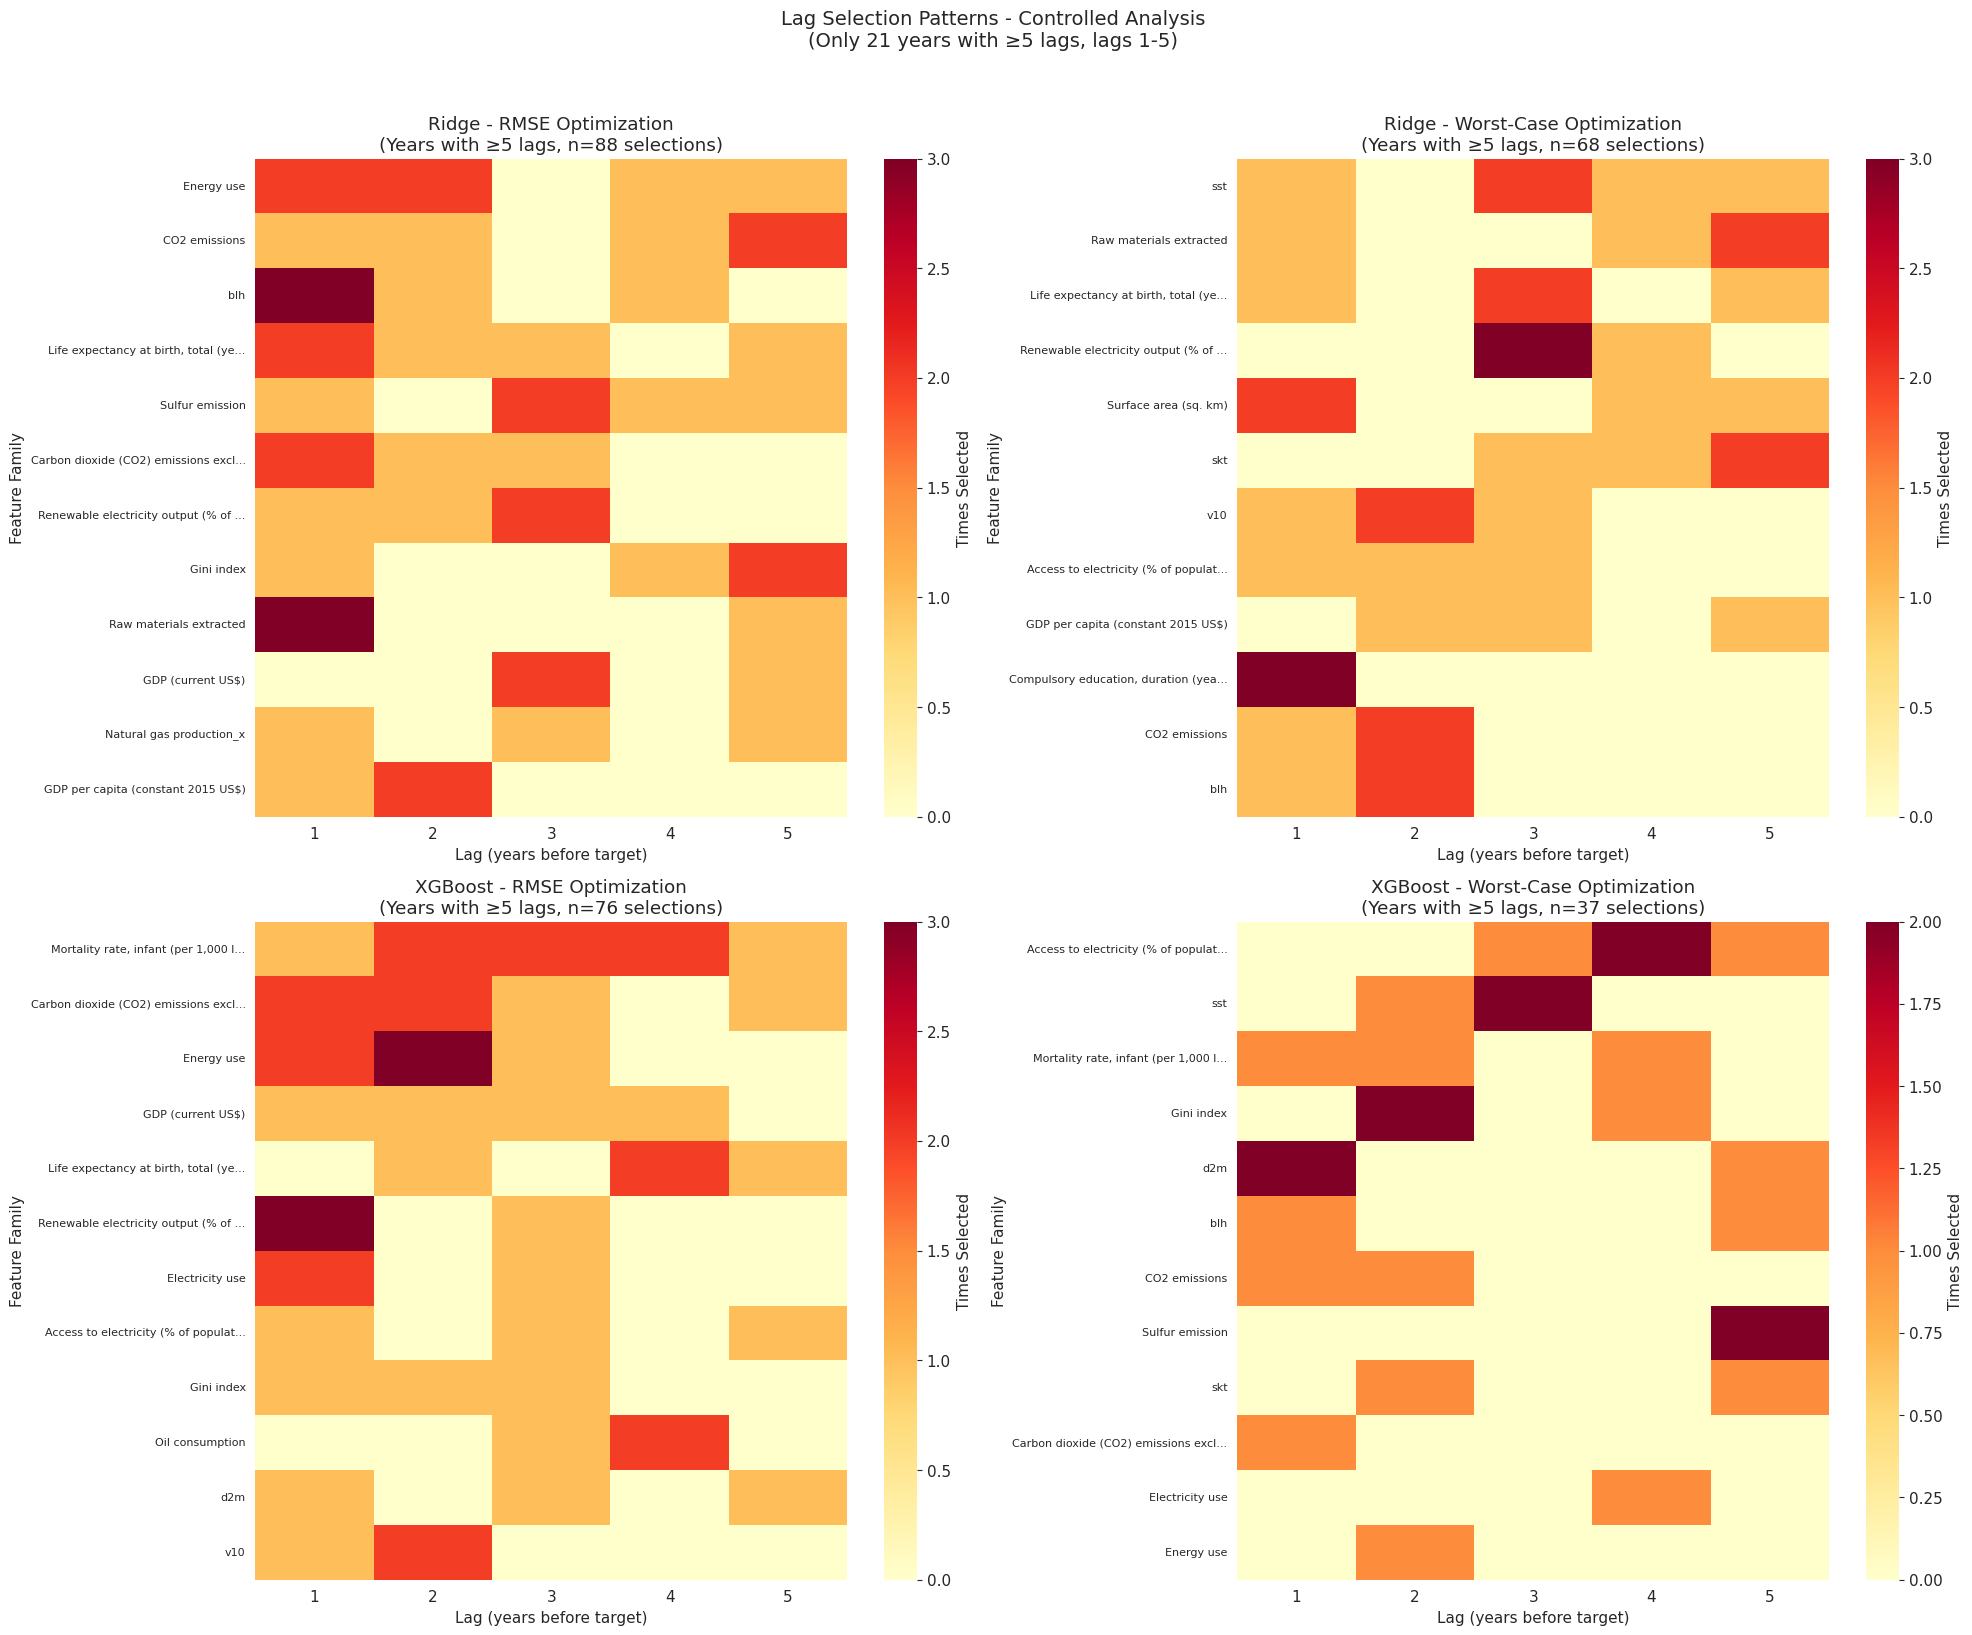


Lag distribution (years with ≥5 lags):
lag
1    75
2    56
3    52
4    38
5    48


In [24]:
# === LAG ANALYSIS WITH CONTROLLED LAG AVAILABILITY ===
# Only consider years that have AT LEAST n lags available

n_lags_to_consider = 5  # <-- CHANGE THIS VALUE: only include years with at least this many lags

# Determine which years have at least n_lags_to_consider lags available
# From the data construction: for target year Y, lags 1 to (Y - min_delta_year) are available
min_year = features_with_lag['year'].min()
years_with_enough_lags = [y for y in features_with_lag['year'].unique() if (y - min_year) >= n_lags_to_consider]

print(f"=" * 80)
print(f"LAG ANALYSIS - ONLY YEARS WITH ≥{n_lags_to_consider} LAGS AVAILABLE")
print(f"=" * 80)
print(f"Years included: {sorted(years_with_enough_lags)}")
print(f"({len(years_with_enough_lags)} years out of {len(features_with_lag['year'].unique())} total)")

# Filter features to only include these years AND only lags up to n_lags_to_consider
filtered_features = features_with_lag[
    (features_with_lag['year'].isin(years_with_enough_lags)) &
    (features_with_lag['lag'] <= n_lags_to_consider)
].copy()

print(f"Features after filtering: {len(filtered_features)} (from {len(features_with_lag)} total)")

# Plot lag patterns for all 4 model/metric combinations with filtered data
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

selection_configs = [
    ('Ridge', 'rmse', 'Ridge - RMSE Optimization'),
    ('Ridge', 'worst_case', 'Ridge - Worst-Case Optimization'),
    ('XGBoost', 'rmse', 'XGBoost - RMSE Optimization'),
    ('XGBoost', 'worst_case', 'XGBoost - Worst-Case Optimization')
]

for idx, (model, metric, title) in enumerate(selection_configs):
    ax = axes[idx // 2, idx % 2]
    
    # Filter features for this model/metric
    model_metric_features = filtered_features[
        (filtered_features['model'] == model) & 
        (filtered_features['optimized_for'] == metric)
    ]
    
    # Get top families for this specific selection
    model_metric_family_counts = model_metric_features.groupby('family').size().sort_values(ascending=False)
    top_families_for_model = model_metric_family_counts.head(12).index.tolist()
    
    if len(model_metric_features) > 0 and len(top_families_for_model) > 0:
        # Create lag-family matrix for this model/metric
        lag_family_data = model_metric_features[model_metric_features['family'].isin(top_families_for_model)]
        lag_family_matrix_mm = lag_family_data.groupby(['family', 'lag']).size().unstack(fill_value=0)
        
        # Reorder rows by total count
        row_order_mm = lag_family_matrix_mm.sum(axis=1).sort_values(ascending=False).index
        lag_family_matrix_mm = lag_family_matrix_mm.loc[row_order_mm]
        
        # Plot heatmap
        sns.heatmap(lag_family_matrix_mm, cmap='YlOrRd', annot=False, ax=ax, 
                    cbar_kws={'label': 'Times Selected'})
        ax.set_xlabel('Lag (years before target)')
        ax.set_ylabel('Feature Family')
        ax.set_title(f'{title}\n(Years with ≥{n_lags_to_consider} lags, n={len(model_metric_features)} selections)')
        
        ax.set_yticklabels([f[:35] + '...' if len(str(f)) > 35 else f 
                           for f in lag_family_matrix_mm.index], fontsize=8, rotation=0)
    else:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', fontsize=12)
        ax.set_title(title)

plt.suptitle(f'Lag Selection Patterns - Controlled Analysis\n(Only {len(years_with_enough_lags)} years with ≥{n_lags_to_consider} lags, lags 1-{n_lags_to_consider})', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Overall lag distribution for filtered data
print(f"\nLag distribution (years with ≥{n_lags_to_consider} lags):")
lag_dist = filtered_features['lag'].value_counts().sort_index()
print(lag_dist.to_string())

BIAS-CORRECTED LAG ANALYSIS
Normalizing by lag availability (# years where each lag was possible)
⚠ Ignoring the last 5 lags (highest values)

Lag range: 1 to 21 (original max: 26)

Lag availability (# target years where each lag is possible):
  Lag  1: available in 25 years
  Lag  5: available in 21 years
  Lag 10: available in 16 years
  Lag 15: available in 11 years
  Lag 20: available in 7 years
  Lag 21: available in 7 years


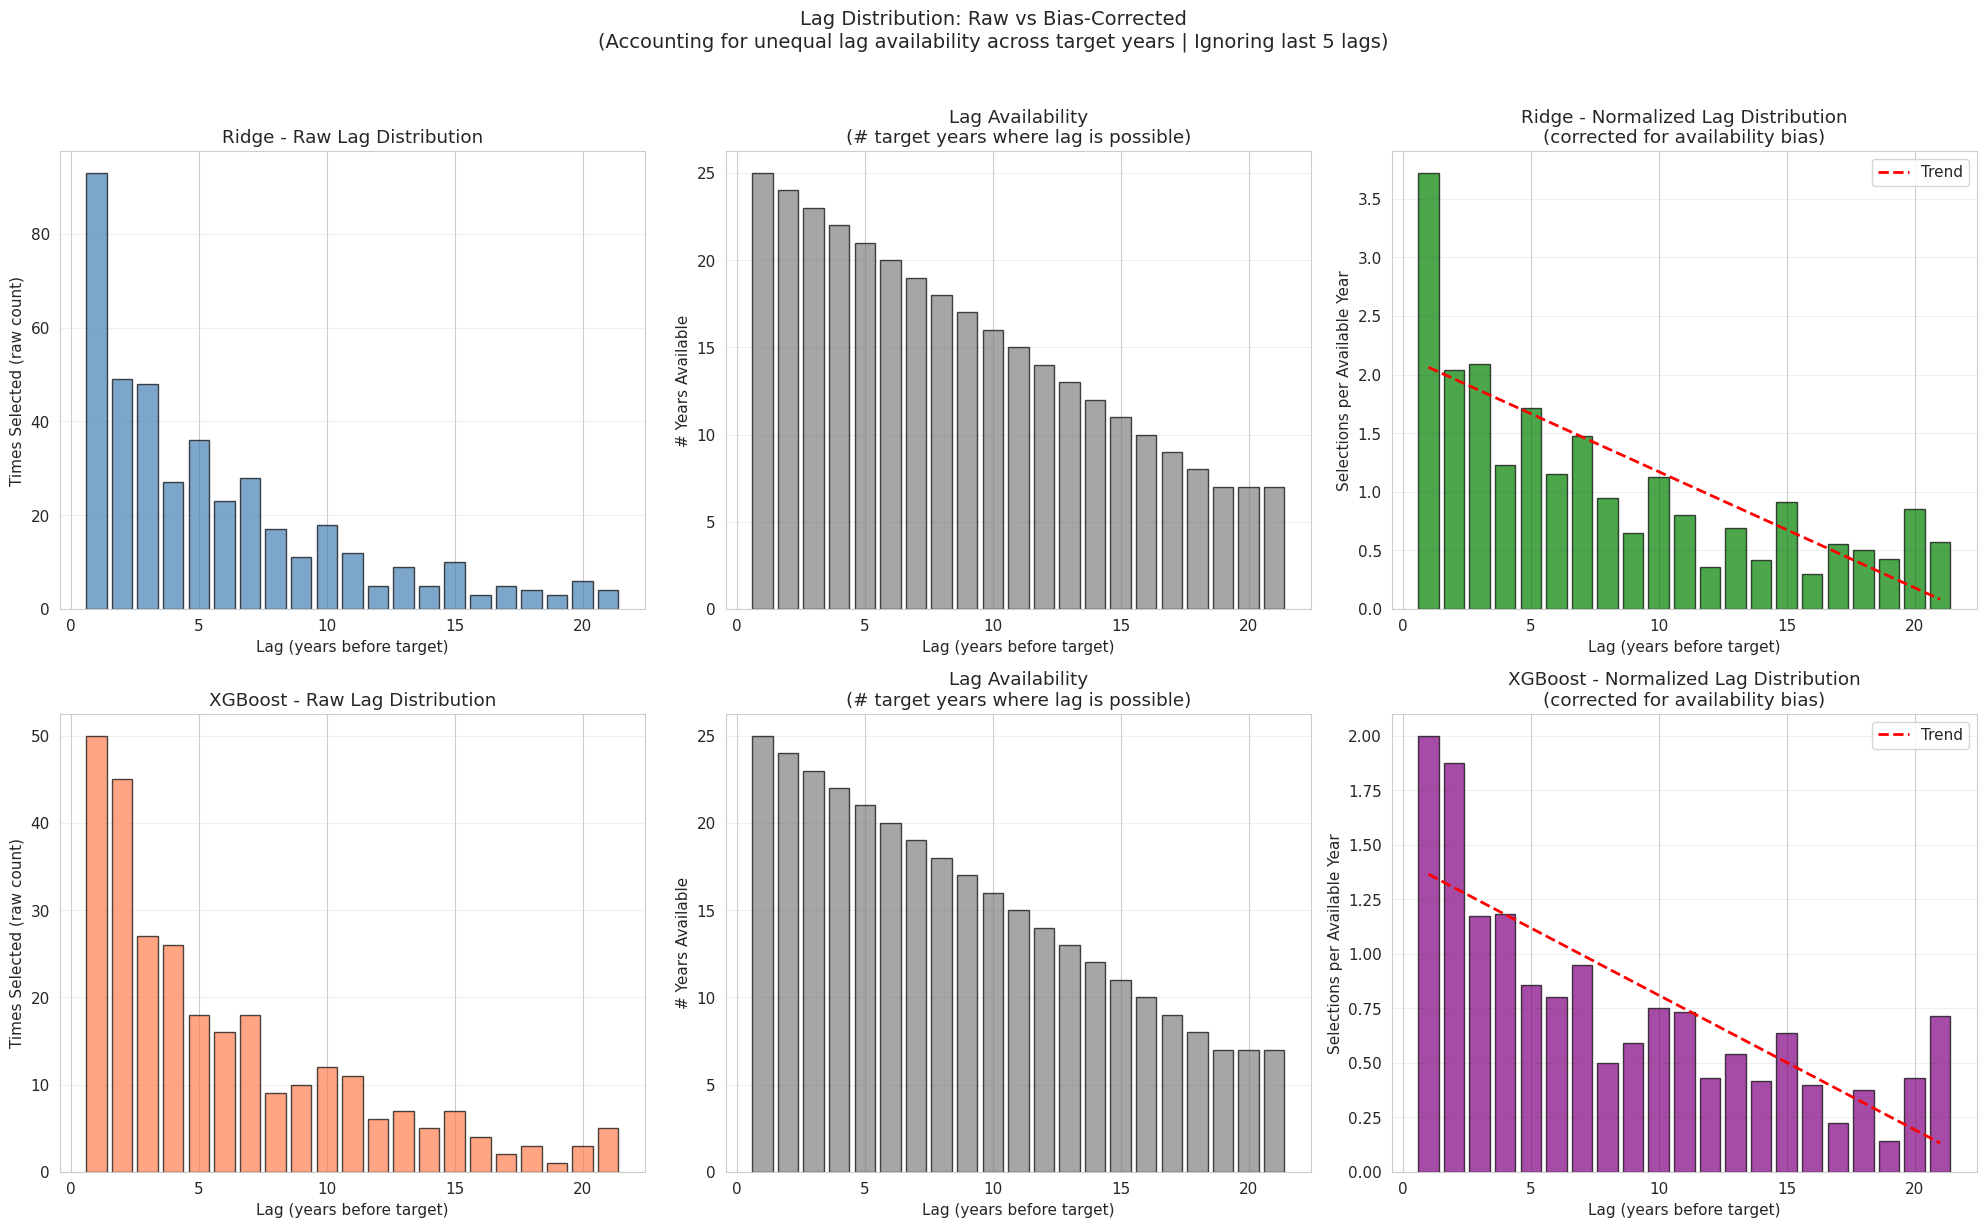


NORMALIZED LAG PATTERNS BY FEATURE FAMILY


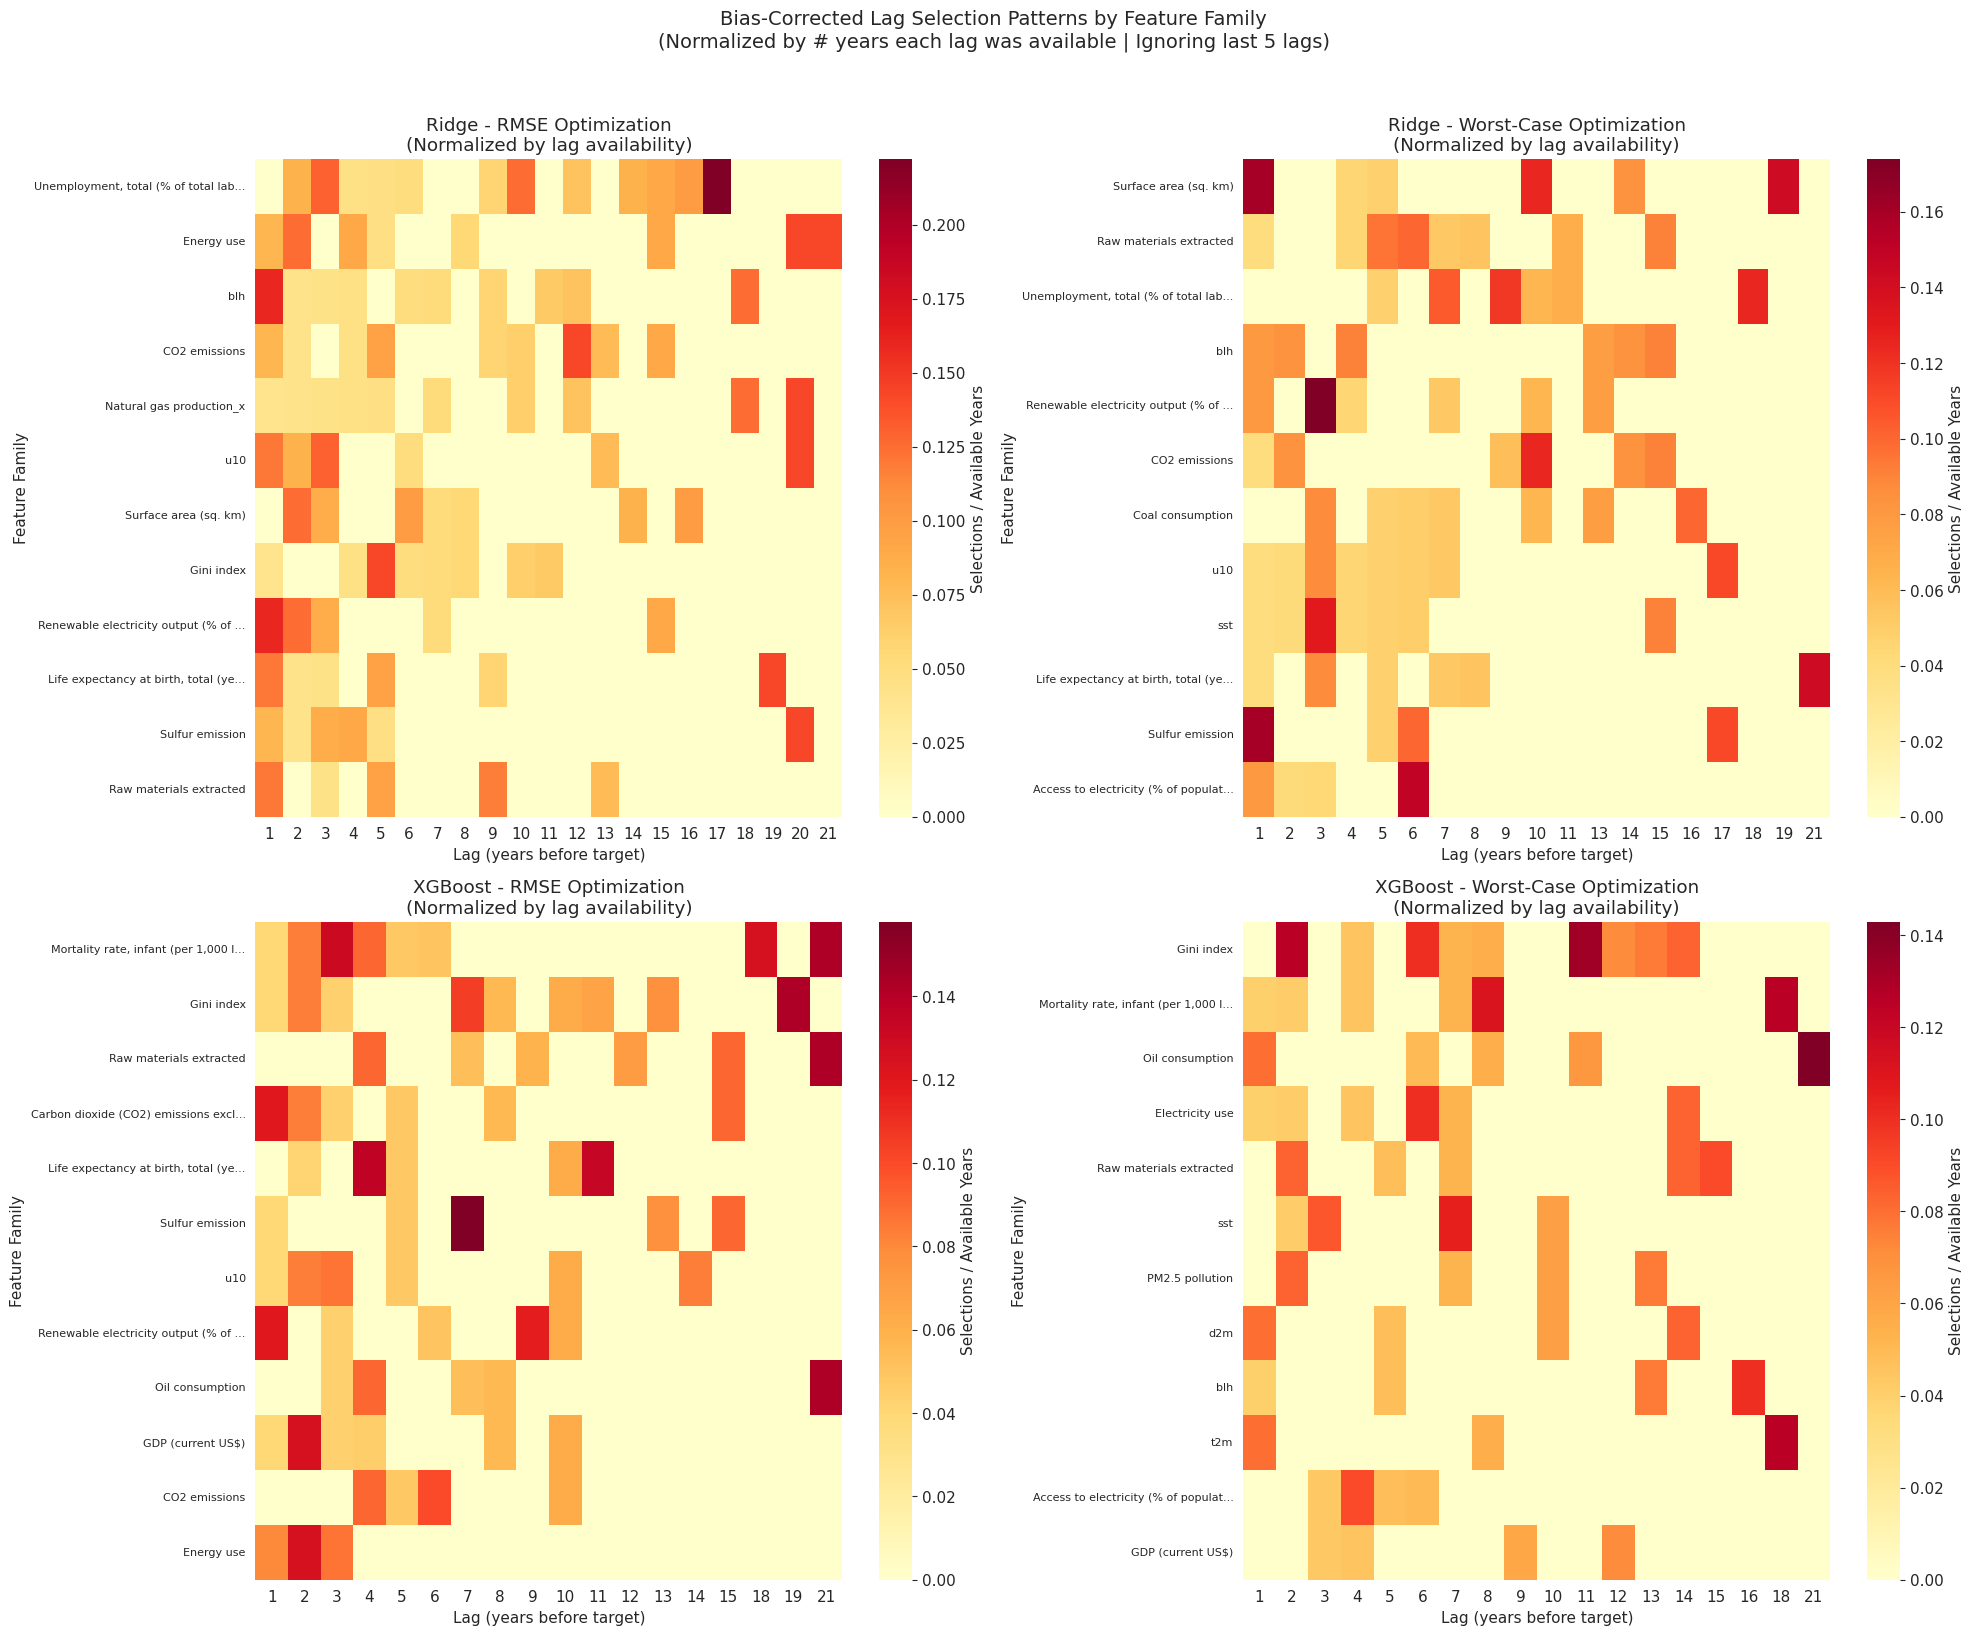


Bias-corrected lag preferences:

Ridge - RMSE Optimization:
  Peak lag (normalized): 1 years
  Top 3 lags (normalized): [1, 2, 3]

Ridge - Worst-Case Optimization:
  Peak lag (normalized): 1 years
  Top 3 lags (normalized): [1, 3, 5]

XGBoost - RMSE Optimization:
  Peak lag (normalized): 1 years
  Top 3 lags (normalized): [1, 2, 3]

XGBoost - Worst-Case Optimization:
  Peak lag (normalized): 1 years
  Top 3 lags (normalized): [1, 2, 6]


In [25]:
# === BIAS-CORRECTED LAG ANALYSIS ===
# Normalize lag counts by the number of years each lag was available

ignore_last_n_lags = 5  # <-- CHANGE THIS VALUE: ignore the last n lags (highest lag values)

print("=" * 80)
print("BIAS-CORRECTED LAG ANALYSIS")
print("Normalizing by lag availability (# years where each lag was possible)")
if ignore_last_n_lags > 0:
    print(f"⚠ Ignoring the last {ignore_last_n_lags} lags (highest values)")
print("=" * 80)

# Calculate how many years each lag was available
# For lag L, it's available for years where (year - min_year) >= L
all_years = sorted(features_with_lag['year'].unique())
min_year = min(all_years)
max_lag_raw = features_with_lag['lag'].max()
max_lag = max_lag_raw - ignore_last_n_lags  # Apply the filter

# Filter features to exclude ignored lags
features_for_bias_analysis = features_with_lag[features_with_lag['lag'] <= max_lag].copy()

lag_availability = {}
for lag in range(1, max_lag + 1):
    years_with_this_lag = [y for y in all_years if (y - min_year) >= lag]
    lag_availability[lag] = len(years_with_this_lag)

print(f"\nLag range: 1 to {max_lag} (original max: {max_lag_raw})")
print("\nLag availability (# target years where each lag is possible):")
display_lags = [l for l in [1, 5, 10, 15, 20, 25, max_lag] if l <= max_lag]
for lag in display_lags:
    if lag in lag_availability:
        print(f"  Lag {lag:2d}: available in {lag_availability[lag]} years")

# Compute normalized lag distribution
# For each model/metric, divide raw counts by availability
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# First column: Raw lag distribution
# Second column: Lag availability
# Third column: Normalized (raw / availability)

for row_idx, model in enumerate(['Ridge', 'XGBoost']):
    # Get data for this model (all metrics combined)
    model_features = features_for_bias_analysis[features_for_bias_analysis['model'] == model]
    
    # Raw counts
    raw_lag_counts = model_features['lag'].value_counts().sort_index()
    
    # Availability counts (multiply by 2 for the two metrics, times number of families per year)
    availability_series = pd.Series(lag_availability).sort_index()
    
    # Normalized: raw / availability
    # This gives "selections per available year" for each lag
    normalized_counts = raw_lag_counts / availability_series[raw_lag_counts.index]
    
    # Plot raw
    ax = axes[row_idx, 0]
    ax.bar(raw_lag_counts.index, raw_lag_counts.values, color='steelblue' if model == 'Ridge' else 'coral', 
           edgecolor='black', alpha=0.7)
    ax.set_xlabel('Lag (years before target)')
    ax.set_ylabel('Times Selected (raw count)')
    ax.set_title(f'{model} - Raw Lag Distribution')
    ax.grid(axis='y', alpha=0.3)
    
    # Plot availability
    ax = axes[row_idx, 1]
    ax.bar(availability_series.index, availability_series.values, color='gray', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Lag (years before target)')
    ax.set_ylabel('# Years Available')
    ax.set_title(f'Lag Availability\n(# target years where lag is possible)')
    ax.grid(axis='y', alpha=0.3)
    
    # Plot normalized
    ax = axes[row_idx, 2]
    ax.bar(normalized_counts.index, normalized_counts.values, 
           color='green' if model == 'Ridge' else 'purple', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Lag (years before target)')
    ax.set_ylabel('Selections per Available Year')
    ax.set_title(f'{model} - Normalized Lag Distribution\n(corrected for availability bias)')
    ax.grid(axis='y', alpha=0.3)
    
    # Add trend line
    z = np.polyfit(normalized_counts.index, normalized_counts.values, 1)
    p = np.poly1d(z)
    ax.plot(normalized_counts.index, p(normalized_counts.index), 'r--', linewidth=2, label='Trend')
    ax.legend()

suptitle_suffix = f" | Ignoring last {ignore_last_n_lags} lags" if ignore_last_n_lags > 0 else ""
plt.suptitle(f'Lag Distribution: Raw vs Bias-Corrected\n(Accounting for unequal lag availability across target years{suptitle_suffix})', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Normalized heatmaps by feature family
print("\n" + "=" * 80)
print("NORMALIZED LAG PATTERNS BY FEATURE FAMILY")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

for idx, (model, metric, title) in enumerate(selection_configs):
    ax = axes[idx // 2, idx % 2]
    
    model_metric_features = features_for_bias_analysis[
        (features_for_bias_analysis['model'] == model) & 
        (features_for_bias_analysis['optimized_for'] == metric)
    ]
    
    model_metric_family_counts = model_metric_features.groupby('family').size().sort_values(ascending=False)
    top_families_for_model = model_metric_family_counts.head(12).index.tolist()
    
    if len(model_metric_features) > 0 and len(top_families_for_model) > 0:
        lag_family_data = model_metric_features[model_metric_features['family'].isin(top_families_for_model)]
        lag_family_matrix_mm = lag_family_data.groupby(['family', 'lag']).size().unstack(fill_value=0)
        
        # Normalize each column (lag) by its availability
        for lag in lag_family_matrix_mm.columns:
            if lag in lag_availability and lag_availability[lag] > 0:
                lag_family_matrix_mm[lag] = lag_family_matrix_mm[lag] / lag_availability[lag]
        
        row_order_mm = lag_family_matrix_mm.sum(axis=1).sort_values(ascending=False).index
        lag_family_matrix_mm = lag_family_matrix_mm.loc[row_order_mm]
        
        sns.heatmap(lag_family_matrix_mm, cmap='YlOrRd', annot=False, ax=ax, 
                    cbar_kws={'label': 'Selections / Available Years'})
        ax.set_xlabel('Lag (years before target)')
        ax.set_ylabel('Feature Family')
        ax.set_title(f'{title}\n(Normalized by lag availability)')
        
        ax.set_yticklabels([f[:35] + '...' if len(str(f)) > 35 else f 
                           for f in lag_family_matrix_mm.index], fontsize=8, rotation=0)
    else:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', fontsize=12)
        ax.set_title(title)

plt.suptitle(f'Bias-Corrected Lag Selection Patterns by Feature Family\n(Normalized by # years each lag was available{suptitle_suffix})', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics
print("\nBias-corrected lag preferences:")
for model, metric, title in selection_configs:
    model_metric_features = features_for_bias_analysis[
        (features_for_bias_analysis['model'] == model) & 
        (features_for_bias_analysis['optimized_for'] == metric)
    ]
    
    if len(model_metric_features) > 0:
        raw_counts = model_metric_features['lag'].value_counts().sort_index()
        normalized = raw_counts / pd.Series(lag_availability)[raw_counts.index]
        
        # Find peak lag after normalization
        peak_lag = normalized.idxmax()
        
        print(f"\n{title}:")
        print(f"  Peak lag (normalized): {peak_lag} years")
        print(f"  Top 3 lags (normalized): {normalized.nlargest(3).index.tolist()}")

## 11. True Out-of-Sample Testing

Test on the last n years using **only** features and training data from the previous year.
This is a proper held-out test since the test year was never seen during feature selection.

In [26]:
# === TRUE OUT-OF-SAMPLE TESTING ===
# Test on last n years using ONLY features/training from previous year

n_test_years = 5  # <-- CHANGE THIS VALUE: number of last years to use as test set

print("=" * 80)
print(f"TRUE OUT-OF-SAMPLE TESTING ON LAST {n_test_years} YEARS")
print("Using features selected from previous year + training on previous year's data")
print("=" * 80)

# Import required modules for data loading and modeling
import sys
sys.path.insert(0, '.')
from delta_config import get_config, BASE_PATH, VERSION
from delta_data_prep import prepare_full_pipeline, build_stacked_delta_dataset, get_base_feature_columns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

config = get_config()

# Load base data
print("\nLoading base data...")
df_base, base_feature_cols, all_target_years = prepare_full_pipeline(BASE_PATH, VERSION, config)
print(f"  Base data shape: {df_base.shape}")
print(f"  Available target years: {all_target_years}")

# Determine test years (last n)
test_years = sorted(all_target_years)[-n_test_years:]
print(f"\n  Test years: {test_years}")

# Get features selected for each year from fs_summary
features_by_year_selection = {}
for _, row in fs_summary.iterrows():
    year = int(row['target_year'])
    selection = row['selection']
    features = [f.strip() for f in row['selected_features'].split(' | ')]
    features_by_year_selection[(year, selection)] = features

print(f"  Feature selections loaded for {len(set(k[0] for k in features_by_year_selection.keys()))} years")

# Model configurations
model_configs = [
    ('Ridge', 'rmse', Ridge(alpha=1.0)),
    ('Ridge', 'worst_case', Ridge(alpha=1.0)),
    ('XGBoost', 'rmse', XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, verbosity=0)),
    ('XGBoost', 'worst_case', XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, verbosity=0)),
]

# Storage for test results
test_results = []

for test_year in test_years:
    train_year = test_year - 1
    
    print(f"\n{'─' * 60}")
    print(f"Test Year: {test_year} (using features/training from {train_year})")
    print(f"{'─' * 60}")
    
    # Check if train_year has feature selection results
    if train_year not in [k[0] for k in features_by_year_selection.keys()]:
        print(f"  ⚠ No feature selection for year {train_year}, skipping")
        continue
    
    # Build datasets for train and test years
    train_df, train_features, train_family_map = build_stacked_delta_dataset(
        df_base, base_feature_cols, train_year
    )
    test_df, test_features, test_family_map = build_stacked_delta_dataset(
        df_base, base_feature_cols, test_year
    )
    
    if train_df.empty or test_df.empty:
        print(f"  ⚠ Empty dataset for train or test year, skipping")
        continue
    
    # Get actual incidence values for test year to compute final incidence predictions
    # We need Value[test_year] for each country to add to predicted delta
    test_year_incidence = df_base[df_base['Year'] == test_year][['Country Code', 'Value']].copy()
    test_year_incidence.columns = ['Country Code', 'incidence_at_test_year']
    
    # Actual incidence at test_year+1 (ground truth for final comparison)
    next_year_incidence = df_base[df_base['Year'] == test_year + 1][['Country Code', 'Value']].copy()
    next_year_incidence.columns = ['Country Code', 'true_incidence_next_year']
    
    # Merge incidence values into test_df
    test_df = test_df.merge(test_year_incidence, on='Country Code', how='left')
    test_df = test_df.merge(next_year_incidence, on='Country Code', how='left')
    
    # Drop rows where we don't have the next year's incidence
    test_df = test_df.dropna(subset=['true_incidence_next_year', 'incidence_at_test_year'])
    
    if len(test_df) == 0:
        print(f"  ⚠ No complete data for test year {test_year}, skipping")
        continue
    
    print(f"  Train: {len(train_df)} countries, Test: {len(test_df)} countries")
    
    for model_name, metric, model_template in model_configs:
        selection_key = f"{model_name}_{metric}"
        
        # Get features from previous year's selection
        if (train_year, selection_key) not in features_by_year_selection:
            print(f"  ⚠ No {selection_key} selection for year {train_year}")
            continue
        
        selected_features = features_by_year_selection[(train_year, selection_key)]
        
        # Filter to features available in both train and test datasets
        available_train = set(train_df.columns)
        available_test = set(test_df.columns)
        valid_features = [f for f in selected_features if f in available_train and f in available_test]
        
        if len(valid_features) == 0:
            print(f"  ⚠ No valid features for {selection_key}")
            continue
        
        # Prepare data
        X_train = train_df[valid_features].values
        y_train = train_df['target'].values
        X_test = test_df[valid_features].values
        y_test = test_df['target'].values  # This is delta_incidence
        
        # Normalize (fit on train)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train model on ALL training data (not LOCO - this is true test)
        from sklearn.base import clone
        model = clone(model_template)
        model.fit(X_train_scaled, y_train)
        
        # Predict delta_incidence
        delta_pred = model.predict(X_test_scaled)
        
        # Convert to actual incidence: predicted_incidence = incidence_at_test_year + delta_pred
        incidence_pred = test_df['incidence_at_test_year'].values + delta_pred
        incidence_true = test_df['true_incidence_next_year'].values
        
        # Also compute metrics for delta directly
        delta_true = y_test
        
        # Metrics for DELTA prediction
        delta_errors = delta_pred - delta_true
        delta_rmse = np.sqrt(np.mean(delta_errors ** 2))
        delta_worst = np.max(np.abs(delta_errors))
        
        # Metrics for INCIDENCE prediction (what we really care about)
        incidence_errors = incidence_pred - incidence_true
        incidence_rmse = np.sqrt(np.mean(incidence_errors ** 2))
        incidence_worst = np.max(np.abs(incidence_errors))
        
        # Baseline: predict incidence stays same (delta = 0)
        baseline_pred = test_df['incidence_at_test_year'].values
        baseline_errors = baseline_pred - incidence_true
        baseline_rmse = np.sqrt(np.mean(baseline_errors ** 2))
        baseline_worst = np.max(np.abs(baseline_errors))
        
        test_results.append({
            'test_year': test_year,
            'train_year': train_year,
            'model': model_name,
            'optimize_metric': metric,
            'selection': selection_key,
            'n_features': len(valid_features),
            'n_countries': len(test_df),
            'delta_rmse': delta_rmse,
            'delta_worst_case': delta_worst,
            'incidence_rmse': incidence_rmse,
            'incidence_worst_case': incidence_worst,
            'baseline_rmse': baseline_rmse,
            'baseline_worst_case': baseline_worst,
        })
        
        print(f"  {selection_key}: {len(valid_features)} features")
        print(f"    Delta RMSE: {delta_rmse:.4f}, Worst: {delta_worst:.4f}")
        print(f"    Incidence RMSE: {incidence_rmse:.4f}, Worst: {incidence_worst:.4f}")
        print(f"    Baseline RMSE: {baseline_rmse:.4f}, Worst: {baseline_worst:.4f}")

# Create results DataFrame
test_results_df = pd.DataFrame(test_results)
print("\n" + "=" * 80)
print("TEST RESULTS SUMMARY")
print("=" * 80)
display(test_results_df)

TRUE OUT-OF-SAMPLE TESTING ON LAST 5 YEARS
Using features selected from previous year + training on previous year's data

Loading base data...
LOADING AND IMPUTING BASE DATA
✓ Loaded 773 rows, 42 columns
  Years: 1990 - 2019
  Countries: 57
✓ Target imputation complete. Remaining NaN in Value: 0
⚠ Dropping 3 columns with >50% NaN:
    - Poverty headcount ratio at national poverty lines (% of population) (82.3% NaN)
    - Prevalence tobacco use (70.5% NaN)
    - Total sales of agricultural pesticides (tonnes) (80.9% NaN)
✓ After ffill/bfill: 569 NaN remaining in features
  Applying IterativeImputer for remaining NaN...
✓ After IterativeImputer: 0 NaN remaining
✓ 32 base features identified
✓ Computed deltas for 32 features + incidence
✓ 27 target years available: [np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np

,test_year,train_year,model,optimize_metric,selection,n_features,n_countries,delta_rmse,delta_worst_case,incidence_rmse,incidence_worst_case,baseline_rmse,baseline_worst_case
0,2014,2013,Ridge,rmse,Ridge_rmse,4,9,2.928934,6.757414,2.928934,6.757414,3.245915,5.359513
1,2014,2013,Ridge,worst_case,Ridge_worst_case,4,9,2.252790,4.399440,2.252790,4.399440,3.245915,5.359513
2,2014,2013,XGBoost,rmse,XGBoost_rmse,4,9,2.165487,4.011003,2.165487,4.011003,3.245915,5.359513
3,2014,2013,XGBoost,worst_case,XGBoost_worst_case,2,9,2.065668,3.456873,2.065668,3.456873,3.245915,5.359513
4,2015,2014,Ridge,rmse,Ridge_rmse,7,9,3.141249,6.177978,3.141249,6.177978,2.613086,4.010994
5,2015,2014,Ridge,worst_case,Ridge_worst_case,8,9,2.330564,4.827843,2.330564,4.827843,2.613086,4.010994
6,2015,2014,XGBoost,rmse,XGBoost_rmse,6,9,1.760828,3.881752,1.760828,3.881752,2.613086,4.010994
7,2015,2014,XGBoost,worst_case,XGBoost_worst_case,4,9,1.771714,3.900643,1.771714,3.900643,2.613086,4.010994
8,2016,2015,Ridge,rmse,Ridge_rmse,5,8,3.902949,9.739076,3.902949,9.739076,3.508072,8.295921
9,2016,2015,Ridge,worst_case,Ridge_worst_case,8,8,3.210809,6.656889,3.210809,6.656889,3.508072,8.295921


AGGREGATE METRICS ACROSS 5 TEST YEARS

Mean metrics across all test years:


delta_rmse  delta_worst_case  \
model   optimize_metric selection                                          
Ridge   rmse            Ridge_rmse              4.0846            9.6654   
        worst_case      Ridge_worst_case        3.1839            6.9164   
XGBoost rmse            XGBoost_rmse            2.6071            5.6367   
        worst_case      XGBoost_worst_case      3.3350            6.4531   

                                            incidence_rmse  \
model   optimize_metric selection                            
Ridge   rmse            Ridge_rmse                  4.0846   
        worst_case      Ridge_worst_case            3.1839   
XGBoost rmse            XGBoost_rmse                2.6071   
        worst_case      XGBoost_worst_case          3.3350   

                                            incidence_worst_case  \
model   optimize_metric selection                                  
Ridge   rmse            Ridge_rmse                        9.6654   
        worst_case      Ridge_worst_case                  6.9164   
XGBoost rmse            XGBoost_rmse                      5.6367   
        worst_case      XGBoost_worst_case                6.4531   

                                            baseline_rmse  \
model   optimize_metric selection                           
Ridge   rmse            Ridge_rmse                  3.195   
        worst_case      Ridge_worst_case            3.195   
XGBoost rmse            XGBoost_rmse                3.195   
        worst_case      XGBoost_worst_case          3.195   

                                            baseline_worst_case  n_features  \
model   optimize_metric selection                                             
Ridge   rmse            Ridge_rmse                       6.3546         5.8   
        worst_case      Ridge_worst_case                 6.3546         5.8   
XGBoost rmse            XGBoost_rmse                     6.3546         5.4   
        worst_case      XGBoost_worst_case               6.3546         3.8   

                                            n_countries  
model   optimize_metric selection                        
Ridge   rmse            Ridge_rmse                   42  
        worst_case      Ridge_worst_case             42  
XGBoost rmse            XGBoost_rmse                 42  
        worst_case      XGBoost_worst_case           42

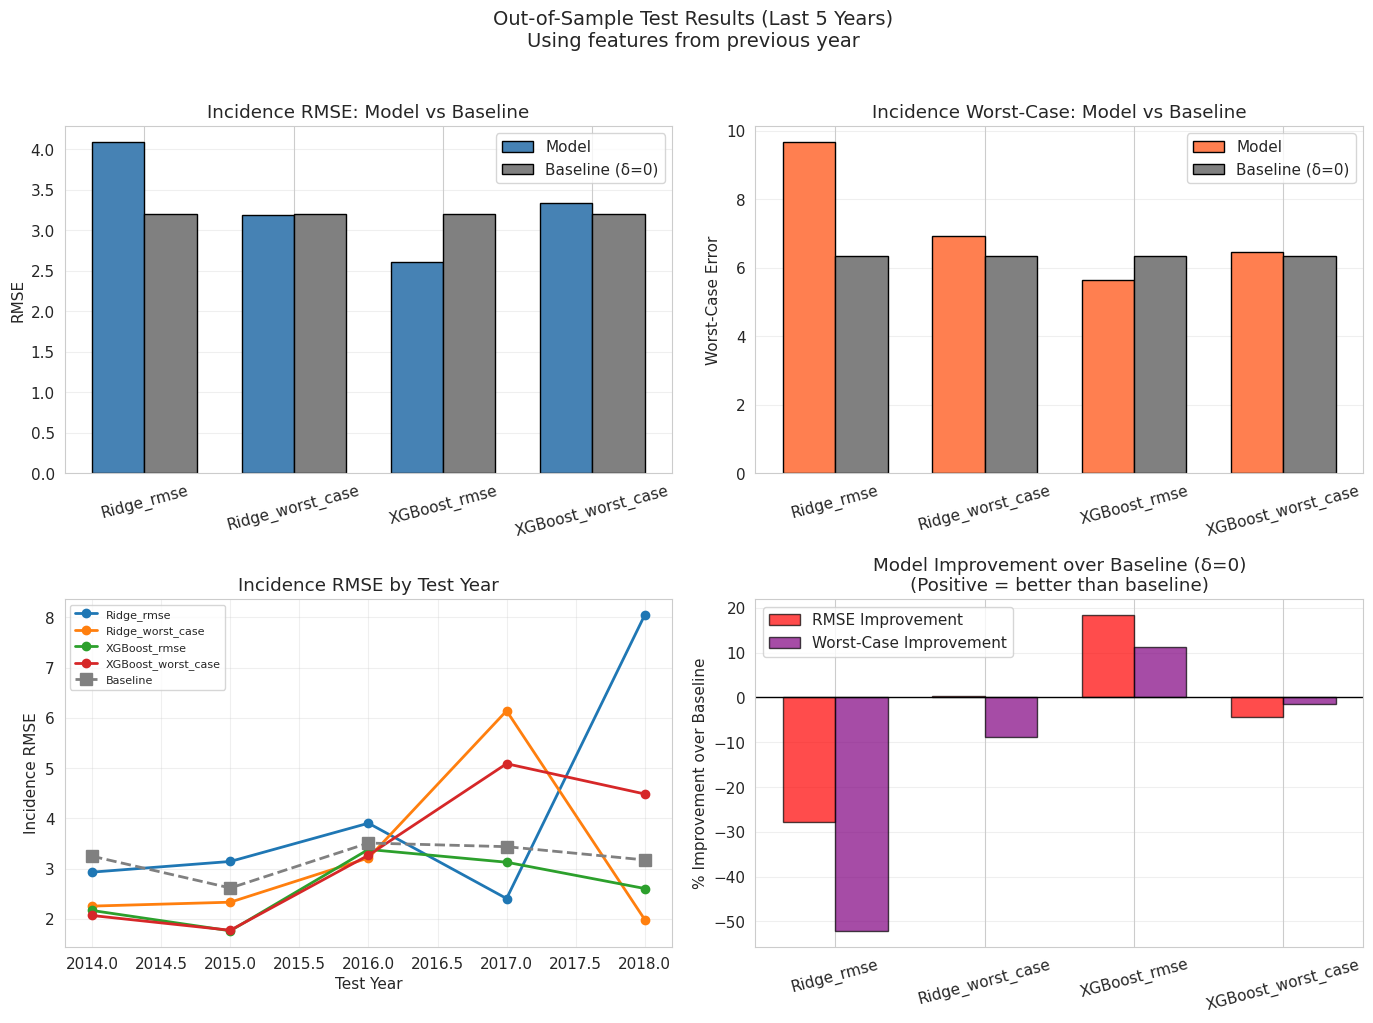


SUMMARY: IMPROVEMENT OVER BASELINE

Ridge_rmse:
  RMSE improvement: -27.8%
  Worst-case improvement: -52.1%

Ridge_worst_case:
  RMSE improvement: +0.3%
  Worst-case improvement: -8.8%

XGBoost_rmse:
  RMSE improvement: +18.4%
  Worst-case improvement: +11.3%

XGBoost_worst_case:
  RMSE improvement: -4.4%
  Worst-case improvement: -1.6%

✓ Best model for RMSE: XGBoost_rmse (+18.4% vs baseline)
✓ Best model for worst-case: XGBoost_rmse (+11.3% vs baseline)


In [27]:
# === AGGREGATE TEST METRICS ACROSS ALL TEST YEARS ===

if len(test_results_df) > 0:
    print("=" * 80)
    print(f"AGGREGATE METRICS ACROSS {n_test_years} TEST YEARS")
    print("=" * 80)
    
    # Aggregate by model/metric combination
    agg_results = test_results_df.groupby(['model', 'optimize_metric', 'selection']).agg({
        'delta_rmse': 'mean',
        'delta_worst_case': 'mean',
        'incidence_rmse': 'mean',
        'incidence_worst_case': 'mean',
        'baseline_rmse': 'mean',
        'baseline_worst_case': 'mean',
        'n_features': 'mean',
        'n_countries': 'sum',
    }).round(4)
    
    print("\nMean metrics across all test years:")
    display(agg_results)
    
    # Comparison plot: Model vs Baseline
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    selections = test_results_df['selection'].unique()
    x = np.arange(len(selections))
    width = 0.35
    
    # Plot 1: Incidence RMSE
    ax = axes[0, 0]
    model_rmse = [test_results_df[test_results_df['selection'] == s]['incidence_rmse'].mean() for s in selections]
    baseline_rmse = [test_results_df[test_results_df['selection'] == s]['baseline_rmse'].mean() for s in selections]
    bars1 = ax.bar(x - width/2, model_rmse, width, label='Model', color='steelblue', edgecolor='black')
    bars2 = ax.bar(x + width/2, baseline_rmse, width, label='Baseline (δ=0)', color='gray', edgecolor='black')
    ax.set_ylabel('RMSE')
    ax.set_title('Incidence RMSE: Model vs Baseline')
    ax.set_xticks(x)
    ax.set_xticklabels(selections, rotation=15)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 2: Incidence Worst-Case
    ax = axes[0, 1]
    model_worst = [test_results_df[test_results_df['selection'] == s]['incidence_worst_case'].mean() for s in selections]
    baseline_worst = [test_results_df[test_results_df['selection'] == s]['baseline_worst_case'].mean() for s in selections]
    bars1 = ax.bar(x - width/2, model_worst, width, label='Model', color='coral', edgecolor='black')
    bars2 = ax.bar(x + width/2, baseline_worst, width, label='Baseline (δ=0)', color='gray', edgecolor='black')
    ax.set_ylabel('Worst-Case Error')
    ax.set_title('Incidence Worst-Case: Model vs Baseline')
    ax.set_xticks(x)
    ax.set_xticklabels(selections, rotation=15)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 3: Performance by test year
    ax = axes[1, 0]
    for selection in selections:
        sel_data = test_results_df[test_results_df['selection'] == selection]
        ax.plot(sel_data['test_year'], sel_data['incidence_rmse'], 'o-', label=selection, linewidth=2, markersize=6)
    # Add baseline
    baseline_by_year = test_results_df.groupby('test_year')['baseline_rmse'].mean()
    ax.plot(baseline_by_year.index, baseline_by_year.values, 's--', color='gray', linewidth=2, 
            markersize=8, label='Baseline')
    ax.set_xlabel('Test Year')
    ax.set_ylabel('Incidence RMSE')
    ax.set_title('Incidence RMSE by Test Year')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Improvement over baseline
    ax = axes[1, 1]
    improvement_rmse = []
    improvement_worst = []
    for selection in selections:
        sel_data = test_results_df[test_results_df['selection'] == selection]
        rmse_imp = 100 * (sel_data['baseline_rmse'].mean() - sel_data['incidence_rmse'].mean()) / sel_data['baseline_rmse'].mean()
        worst_imp = 100 * (sel_data['baseline_worst_case'].mean() - sel_data['incidence_worst_case'].mean()) / sel_data['baseline_worst_case'].mean()
        improvement_rmse.append(rmse_imp)
        improvement_worst.append(worst_imp)
    
    bars1 = ax.bar(x - width/2, improvement_rmse, width, label='RMSE Improvement', 
                   color='green' if np.mean(improvement_rmse) > 0 else 'red', edgecolor='black', alpha=0.7)
    bars2 = ax.bar(x + width/2, improvement_worst, width, label='Worst-Case Improvement', 
                   color='purple', edgecolor='black', alpha=0.7)
    ax.axhline(0, color='black', linestyle='-', linewidth=1)
    ax.set_ylabel('% Improvement over Baseline')
    ax.set_title('Model Improvement over Baseline (δ=0)\n(Positive = better than baseline)')
    ax.set_xticks(x)
    ax.set_xticklabels(selections, rotation=15)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.suptitle(f'Out-of-Sample Test Results (Last {n_test_years} Years)\nUsing features from previous year', 
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "=" * 80)
    print("SUMMARY: IMPROVEMENT OVER BASELINE")
    print("=" * 80)
    for i, selection in enumerate(selections):
        print(f"\n{selection}:")
        print(f"  RMSE improvement: {improvement_rmse[i]:+.1f}%")
        print(f"  Worst-case improvement: {improvement_worst[i]:+.1f}%")
    
    # Overall best model
    best_idx = np.argmax(improvement_rmse)
    print(f"\n✓ Best model for RMSE: {selections[best_idx]} ({improvement_rmse[best_idx]:+.1f}% vs baseline)")
    best_idx_worst = np.argmax(improvement_worst)
    print(f"✓ Best model for worst-case: {selections[best_idx_worst]} ({improvement_worst[best_idx_worst]:+.1f}% vs baseline)")
else:
    print("⚠ No test results to display")